In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.stats as stats
from collections import Counter

In [2]:
DELTA = 0.001 * math.pi

In [3]:
class Task:
    def __init__(self, tid):
        self.id = tid
        self.parents = []  # list of (parent_id, data_MB)

    def add_parent(self, pid, data):
        self.parents.append((pid, data))

In [4]:
class Node:
    def __init__(self, nid, bw=1000, cpr=1.0, ctr=0.05):
        self.id = nid
        self.bw = bw
        self.cpr = cpr
        self.ctr = ctr
        self.name = f"Node{nid}"

In [5]:
def load_etc(path):
    vals = []
    with open(path, "r") as f:
        lines = [l.strip() for l in f if l.strip()]

    # First line: T N
    T, N = map(int, lines[0].split())

    # Remaining: T*N values in a column
    for v in lines[1:]:
        vals.append(float(v))

    etc = np.array(vals).reshape(T, N)
    return etc

In [6]:
def load_tt(path):
    with open(path, "r") as f:
        lines = [l.strip() for l in f if l.strip()]

    n = int(lines[0])
    data = []
    for i in range(1, 1+n):
        row = list(map(float, lines[i].split()))
        data.append(row)

    return np.array(data)

In [7]:
def build_tasks(tt):
    T = tt.shape[0]
    tasks = [Task(i) for i in range(T)]

    for i in range(T):
        for j in range(T):
            if tt[i][j] > 0:
                tasks[j].add_parent(i, tt[i][j])

    return tasks

In [8]:
def plot_dag(tasks, name):
    G = nx.DiGraph()

    for t in tasks:
        G.add_node(t.id)

    for t in tasks:
        for (p, data) in t.parents:
            G.add_edge(p, t.id, weight=data)

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=700)
    nx.draw_networkx_labels(G, pos)
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20)

    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    plt.title(f"{name} Workflow DAG")
    plt.axis("off")
    plt.show()

In [9]:
def bits_per_node(N):
    return math.ceil(math.log2(N)) + 1 #Mapping resources to bits

In [10]:
def measure_qubit(a, b):
    return 1 if random.random() > a*a else 0

In [11]:
def measure_chromosome(qchrom, bpn):
    total_bits = len(qchrom)*bpn
    bits = [0]*total_bits
    for i, (a,b) in enumerate(qchrom):
        bits[i] = measure_qubit(a,b)
    return bits

In [12]:
def decode(bits, T, N):
    bpn = bits_per_node(N)
    assign = []
    for t in range(T):
        chunk = bits[t*bpn:(t+1)*bpn]
        x = 0
        for bit in chunk:
            x = (x << 1) | bit
        assign.append(x % N)
    return assign

In [13]:
def get_rotation_angle(x, b, fit_x, fit_best, a, beta, DELTA):
    condition = (fit_x >= fit_best) # current makespan i worse or equal
    
    #By table 1 logic
    if x == 0 and b == 0:
        return 0
    elif x == 0 and b == 1:
        if not condition:#f(x) < f(b)
            s = 1 if a*beta > 0 else -1 if a*beta < 0 else 0 if a == 0 else 1
        else:
            s = -1 if a*beta > 0 else 1 if a*beta < 0 else 1 if a == 0 else 0
        return s*DELTA
    elif x == 1 and b == 0:
        if not condition:
            s = -1 if a*beta > 0 else 1 if a*beta < 0 else 1 if a == 0 else 0
        else:
            s = 1 if a*beta > 0 else -1 if a*beta < 0 else 0 if a == 0 else 1
        return s*DELTA
    elif x == 1 and b == 1:
        return 0
    return 0

In [14]:
def rotate(a, b, theta):
    c, s = math.cos(theta), math.sin(theta)
    a2 = c*a - s*b
    b2 = s*a + c*b
    norm = math.sqrt(a2**2 + b2**2)
    return a2/norm, b2/norm

In [15]:
def calculate_upward_rank(tasks, etc, tt):
    T = len(tasks)
    rank = {}

    def get_rank(tid):
        if tid in rank:
            return rank[tid]
        avg_w = np.mean(etc[tid])
        successors = [j for j in range(T) if tt[tid][j] > 0]
        if not successors:
            rank[tid] = avg_w
        else:
            max_val = max(tt[tid][s]/(1000/8) + get_rank(s) for s in successors)
            rank[tid] = avg_w + max_val
        return rank[tid]
    for i in range(T):
        get_rank(i)
    return sorted(range(T), key=lambda i: rank[i], reverse=True)

# Quantum Mutaion

In [16]:
def quantum_mutation(qchrom, pm):
    "Swap alpha and beta for a qubit with probability pm"
    for i in range(len(qchrom)):
        if random.random() < pm:
            a, b = qchrom[i]
            qchrom[i] = (b, a) #Swap amplitudes
    return qchrom

# Compute Makespan

In [17]:
def compute_makespan(tasks, nodes, etc, assignment):
    T = len(tasks)
    EST = [0]*T
    EFT = [0]*T
    #total_cost = 0.0 #initializing the cost tracker
    
    # Topological order
    indeg = {t.id: 0 for t in tasks}
    edges = {t.id: [] for t in tasks}

    for t in tasks:
        for (p, d) in t.parents:
            indeg[t.id] += 1
            edges[p].append((t.id, d))

    Q = [i for i in indeg if indeg[i] == 0]
    topo = []
    while Q:
        u = Q.pop(0)
        topo.append(u)
        for (v,_) in edges[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                Q.append(v)

    for tid in topo:
        task = tasks[tid]
        node_idx = assignment[tid]

        start = 0
        for (p, data) in task.parents:
            p_node = assignment[p]
            finish_p = EFT[p]

            if p_node == node_idx:
                trans = 0
            else:
                bw = min(nodes[node_idx].bw, nodes[p_node].bw)
                trans = data / (bw/8)

            start = max(start, finish_p + trans)

        dur = etc[tid][node_idx]
        EST[tid] = start
        EFT[tid] = start + dur
    
    cmpw = 0.0 #Computational Cost
    ccpw = 0.0 #Communication Cost
    for i in range(T):
        n_idx = assignment[i]
        cmpw += (EFT[i] - EST[i])*nodes[n_idx].cpr #Execution duration * node computation price

        for (pid, data) in tasks[i].parents:
            p_node = assignment[pid]
            if n_idx != p_node:
                trans_time = data/(min(nodes[n_idx].bw,nodes[p_node].bw)/8)
                ccpw += trans_time*nodes[p_node].ctr
    total_cost = cmpw + ccpw
    makespan = max(EFT)
    schedule_data = [(EST[i], total_cost, EFT[i], assignment[i]) for i in range(T)]

    return makespan, total_cost, schedule_data

In [18]:
def evaluate_chromosome(tasks, nodes, etc, assignment, deadline):
    ms, cost, schedule = compute_makespan(tasks, nodes, etc, assignment)
    if ms <= deadline:
        fit_x = cost
    else:
        fit_x = 1000000.0 + ms
    return fit_x, ms, cost, schedule

# Standard SQGA

In [19]:
def init_population(pop, T, N):
    bpn = bits_per_node(N)
    M = T*bpn
    a0 = 1.0/math.sqrt(N)
    return [[(a0,a0)for _ in range(M)]for _ in range(pop)]

In [20]:
def sqga_standard(tasks, nodes, etc, deadline, pop = 20, gens = 100, pm = 0.01, w1 = 0.5, w2= 0.5):
    T = len(tasks)
    N = len(nodes)
    bpn = bits_per_node(N)
    population = init_population(pop, T, N)
    M = T*bpn

    best_fitness = float('inf')
    best_ms, best_cost = float('inf'), float('inf')
    best_bits, best_assign, best_sched = None, None, None
    history = []

    for g in range(gens):
        fitness = []
        measured = []
        for qchrom in population:
            #Standard Population
            bits = measure_chromosome(qchrom, bpn)
            measured.append(bits)
            assign = decode(bits, T, N)
            #ms, cost, schedule = compute_makespan(tasks, nodes, etc, assign)
            #combined_fitness = (w1*ms) + (w2*cost)
            #fitness.append(combined_fitness)
            fit_x, ms, cost, schedule = evaluate_chromosome(tasks, nodes, etc, assign, deadline)
            fitness.append(fit_x)
            
            if fit_x < best_fitness:
                best_fitness = fit_x
                best_ms = ms
                best_cost = cost
                best_bits = bits.copy()
                best_assign = assign.copy()
                best_sched = schedule
        newpop = []
        for i in range(pop):
            qchrom = population[i]
            bits = measured[i]
            fit_y = fitness[i]

            updated_qchrom = []
            for j in range(M):
                a, b = qchrom[j]
                theta = get_rotation_angle(bits[j], best_bits[j], fit_y, best_fitness, a, b, DELTA)
                updated_qchrom.append(rotate(a, b, theta))
            
            mutated_qchrom = quantum_mutation(updated_qchrom, pm)
            newpop.append(mutated_qchrom)

            if g == 0 and i == 0:
                j = 0
                a_old, b_old = qchrom[j]
                theta = get_rotation_angle(bits[j], best_bits[j], fit_x, best_fitness, a_old, b_old, DELTA)
                a_new, b_new = rotate(a_old, b_old, theta)
                print(f"\n--- Rotation Gate Check (Gen {g}, Ind {i}, Qubit {j}) ---")
                print(f"Bit was: {bits[j]}, Target was: {best_bits[j]}, Angle: {theta:.6f}")
                print(f"Old State: α={a_old:.4f}, β={b_old:.4f} (Prob of '1' = {b_old**2:.4f})")
                print(f"New State: α={a_new:.4f}, β={b_new:.4f} (Prob of '1' = {b_new**2:.4f})")
        population = newpop
                
        history.append((best_ms, best_cost))
    return best_ms, best_cost, best_assign, best_sched, history

In [21]:
def qcrossover(p1, p2, T, bpn):
    if T < 2: return p1.copy(), p2.copy()
    if T == 2:
        s = bpn
        c1 = p1[:s] + p2[s:]
        c2 = p2[:s] + p1[s:]
        return c1, c2
    pt1, pt2 =  sorted(random.sample(range(T), 2))
    s1, s2 = pt1*bpn, pt2*bpn
    c1 = p1[:s1] + p2[s1:s2] + p1[s2:]
    c2 = p2[:s1] + p1[s1:s2] + p2[s2:]
    return c1, c2

# DGQA Approach

In [22]:
def dqga_approach(bpn, T, qchrom, iter = 15):
    final_bits = []
    num_states = 2**bpn
    for t in range(T):
        qinspired_amp = qchrom[t*bpn:(t+1)*bpn]
        #Convert amplitudes into probability
        state_prob = [1.0]*num_states
        for i in range(num_states):
            for bit_pos in range(bpn):
                alpha, beta = qinspired_amp[bit_pos]
                if (i & (1 << (bpn - 1 - bit_pos))):
                    state_prob[i] *= beta**2
                else:
                    state_prob[i] *= alpha**2
        cf = []
        curr = 0
        for p in state_prob:
            curr += p
            cf.append(curr)
        #Statistical Sampling
        samples = []
        for _ in range(iter):
            r = random.random()
            if cf[-1] > 0:
                r *= cf[-1]
            for start_idx, threshold in enumerate(cf):
                if r < threshold:
                    samples.append(start_idx)
                    break
        if not samples:
            winner_state = 0
        else:
            winner_state = Counter(samples).most_common(1)[0][0]
            winner_bits = [int(b) for b in bin(winner_state)[2:].zfill(bpn)]
            final_bits.extend(winner_bits)
    return final_bits

In [23]:
def dqga(tasks, nodes, etc, deadline, pop = 20, gens = 100, pm = 0.01, pc = 0.8, w1 = 0.5, w2 = 0.5):
    N = len(nodes)
    T = len(tasks)
    bpn = bits_per_node(N)
    chromosome = init_population(pop, T, N)
    M = T*bpn

    indeg = {t.id: 0 for t in tasks}
    edges = {t.id: [] for t in tasks}
    for t in tasks:
        for (p, d) in t.parents:
            indeg[t.id] += 1
            edges[p].append((t.id, d))

    Q = [i for i in indeg if indeg[i] == 0]
    topo = []
    while Q:
        u = Q.pop(0)
        topo.append(u)
        for (v,_) in edges[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                Q.append(v)

    greedy_assign = [0] * T
    EFT_local = [0] * T
    for tid in topo:
        task = tasks[tid]
        best_vm = 0
        best_eft = float('inf')
        for vm in range(N):
            start = 0
            for (p, data) in task.parents:
                p_node = greedy_assign[p]
                finish_p = EFT_local[p]
                if p_node == vm:
                    trans = 0
                else:
                    bw = min(nodes[vm].bw, nodes[p_node].bw)
                    trans = data / (bw / 8)
                start = max(start, finish_p + trans)
            
            eft_val = start + etc[tid][vm]
            if eft_val < best_eft:
                best_eft = eft_val
                best_vm = vm
        greedy_assign[tid] = best_vm
        EFT_local[tid] = best_eft
    # --- 2. Quantum Seeding ---
    # Convert greedy integer assignment to a flat bitstring
    greedy_bits = []
    for vm in greedy_assign:
        b_str = bin(vm)[2:].zfill(bpn)
        greedy_bits.extend([int(x) for x in b_str])

    # Bias chromosome[0] so its amplitudes heavily favor the greedy bits
    seeded_qchrom = []
    for bit in greedy_bits:
        if bit == 1:
            # probability of collapsing to 1 is ~99.9%
            seeded_qchrom.append([0.0316, 0.9995]) 
        else:
            # probability of collapsing to 0 is ~99.9%
            seeded_qchrom.append([0.9995, 0.0316]) 
    chromosome[0] = seeded_qchrom

    best_fitness = float('inf')
    best_ms, best_cost = float('inf'), float('inf')
    best_bits =  [0]*M
    best_assign, best_sched = None, None
    best_qchrom_memory = chromosome[0].copy()
    history = []

    for g in range(gens):
        #implementing 2-point crossover into dqga
        random.shuffle(chromosome)
        next_gen_quantum = []

        for i in range(0, pop - 1, 2):
            parent1 = chromosome[i]
            parent2 = chromosome[i + 1]

            if random.random() < pc:
                child1, child2 = qcrossover(parent1, parent2, T, bpn)
                next_gen_quantum.extend([child1, child2])
            else:
                next_gen_quantum.extend([parent1, parent2])
        if len(next_gen_quantum) < pop:
            next_gen_quantum.append(chromosome[-1])
        chromosome = next_gen_quantum
        # --- 3. Explicit Elitism Injection ---
        if g > 0:
            chromosome[0] = best_qchrom_memory.copy()
        
        fitness = []
        measured = []
        for qchrom in chromosome:
            bits = dqga_approach(bpn, T, qchrom, iter = 15)
            measured.append(bits)
            assign = decode(bits, T, N)
            # ms, cost, schedule = compute_makespan(tasks, nodes, etc, assign)
            #combined_fitness = (w1*ms) + (w2*cost)
            #fitness.append(combined_fitness)
            fit_x, ms, cost, schedule = evaluate_chromosome(tasks, nodes, etc, assign, deadline)
            fitness.append(fit_x)

            if fit_x < best_fitness:
                best_fitness = fit_x
                best_ms = ms
                best_cost = cost
                best_bits = bits.copy()
                best_assign = assign.copy()
                best_sched = schedule
        newchrom = []
        for i in range(pop):
            qchrom = chromosome[i]
            bits = measured[i]
            fit_y = fitness[i]
            
            updated_qchrom = []
            for j in range(M):
                a, b = qchrom[j]
                theta = get_rotation_angle(bits[j], best_bits[j], fit_y, best_fitness, a, b, DELTA)
                updated_qchrom.append(rotate(a, b, theta))

            mutated_qchrom = quantum_mutation(updated_qchrom, pm)
            newchrom.append(mutated_qchrom)

        chromosome = newchrom
        history.append((best_ms, best_cost))

    return best_ms, best_cost, best_assign, best_sched, history

# Quantum Crossover Approach

In [24]:
def qga_crossover(tasks, nodes, etc, pop = 20, gens = 100, pm = 0.01, pc =  0.8, w1 = 0.5, w2 = 0.5):
    T = len(tasks)
    N = len(nodes)
    bpn = bits_per_node(N)
    population = init_population(pop, T, N)
    M = T*bpn

    best_fitness = float('inf')
    best_ms, best_cost = float('inf'), float('inf')
    best_bits, best_assign, best_sched = None, None, None
    history = []

    for g in range(gens):
        random.shuffle(population)
        fitness = []
        measured = []
        for qchrom in population:
            bits = measure_chromosome(qchrom, bpn)
            measured.append(bits)
            assign = decode(bits, T, N)
            ms, cost, schedule = compute_makespan(tasks, nodes, etc, assign)
            combined_fitness = (w1*ms) + (w2*cost)
            fitness.append(combined_fitness)

            if combined_fitness < best_fitness:
                best_fitness = combined_fitness
                best_ms = ms
                best_cost = cost
                best_bits = bits.copy()
                best_assign = assign.copy()
                best_sched = schedule
                
        crossed_pop = []
        for i in range(0, pop - 1, 2):
            p1 = population[i]
            p2 = population[i + 1]

            if random.random() < pc:
                c1, c2 = qcrossover(p1, p2, T, bpn)
                crossed_pop.extend([c1, c2])
            else:
                crossed_pop.extend([p1, p2])
        if len(crossed_pop) < pop:
            crossed_pop.append(population[-1])
        newpop = []
        for i in range(pop):
            qchrom =  crossed_pop[i]
            bits = measured[i]
            fit_x = fitness[i]

            updated_qchrom = []
            for j in range(M):
                a, b = qchrom[j]
                theta = get_rotation_angle(bits[j], best_bits[j], fit_x, best_fitness, a, b, DELTA)
                updated_qchrom.append(rotate(a, b, theta))
            mutated_qchrom = quantum_mutation(updated_qchrom, pm)
            newpop.append(mutated_qchrom)
        population = newpop
        history.append((best_ms, best_cost))
    return best_ms, best_cost, best_assign, best_sched, history

# CQGA

In [25]:
def qmeasure(qchrom):
    bits = []
    for alpha, beta in qchrom:
        if random.random() < alpha**2:
            bits.append(1)
        else:
            bits.append(0)
    return bits

In [26]:
def crossover_qchrom(p1, p2, pc, bpn):
    if random.random() > pc:
        return p1.copy(), p2.copy(), len(p1)
    num_tasks = len(p1)//bpn
    if num_tasks < 2:
        return p1.copy(), p2.copy(), len(p1)
    split_task_idx = random.randint(1, num_tasks - 1)
    split_point = split_task_idx * bpn
    child1 = p1[:split_point] + p2[split_point:]
    child2 = p2[:split_point] + p1[split_point:]
    return child1, child2, split_point

In [27]:
def cqga(tasks, nodes, etc, deadline, pop = 20, gens = 100, pm = 0.01, pc = 0.8, w1 = 0.5, w2 = 0.5):
    N, T = len(nodes), len(tasks)
    bpn = bits_per_node(N)
    M = T*bpn
    chromosomes = init_population(pop, T, N)
    best_fitness, best_ms, best_cost = float('inf'), float('inf'), float('inf')
    best_bits = [0]*M
    best_assign, best_sched = None, None
    history = []
    for tou in range(gens):
        fitness_score = []
        measured_bits_list = []
        for qchrom in chromosomes:
            bits = qmeasure(qchrom)
            measured_bits_list.append(bits)
            assign = decode(bits, T, N)
            #ms, cost, schedule = compute_makespan(tasks, nodes, etc, assign)
            #if ms > deadline:
             #   fit = float('inf')
            #else: 
             #   fit = (w1 * ms) + (w2 * cost)
            #fitness_score.append(fit)
            fit_x, ms, cost, schedule = evaluate_chromosome(tasks, nodes, etc, assign, deadline)
            fitness_score.append(fit_x)
            
            if fit_x < best_fitness:
                best_fitness = fit_x
                best_ms = ms
                best_cost = cost
                best_bits = bits.copy()
                best_assign = assign.copy()
                best_sched = schedule
        newpop = []
        indices = list(range(pop))
        indices.sort(key=lambda x: fitness_score[x])
        for i in range(0, pop, 2):
            idx1 = indices[random.randint(0, pop//2)]
            idx2 = indices[random.randint(0, pop//2)]
            p1, p2 = chromosomes[idx1], chromosomes[idx2]
            c1, c2, split_point = crossover_qchrom(p1, p2, pc, bpn)
            for child_idx, child in enumerate([c1, c2]):
                updated_child = []
                for j in range(M):
                    if child_idx == 0:
                        parent_idx = idx1 if j < split_point else idx2
                    else:
                        parent_idx = idx2 if j < split_point else idx1
                    a, b = child[j]
                    theta = get_rotation_angle(measured_bits_list[parent_idx][j], best_bits[j], fitness_score[parent_idx], best_fitness, a, b, DELTA)
                    updated_child.append(rotate(a, b, theta))
                mutated_child = quantum_mutation(updated_child, pm)
                newpop.append(mutated_child)
        chromosomes = newpop[:pop]
        history.append((best_ms, best_cost))
    return best_ms, best_cost, best_assign, best_sched, history

# Single Point Cross over Genetic Algorithm

In [28]:
def ga_single_point(tasks, nodes, etc, deadline, pop_size=20, gens=100):
    import random
    T, N = len(tasks), len(nodes)
    '''
    indeg = {t.id: 0 for t in tasks}
    edges = {t.id: [] for t in tasks}
    for t in tasks:
        for (p, d) in t.parents:
            indeg[t.id] += 1
            edges[p].append((t.id, d))

    Q = [i for i in indeg if indeg[i] == 0]
    topo = []
    while Q:
        u = Q.pop(0)
        topo.append(u)
        for (v,_) in edges[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                Q.append(v)

    # --- Step 2: Build Greedy Seed strictly aligned with compute_makespan ---
    def get_greedy_seed():
        chrom = [0] * T
        EFT_local = [0] * T
        for tid in topo:
            task = tasks[tid]
            best_vm = 0
            best_eft = float('inf')
            for vm in range(N):
                start = 0
                for (p, data) in task.parents:
                    p_node = chrom[p]
                    finish_p = EFT_local[p]
                    if p_node == vm:
                        trans = 0
                    else:
                        bw = min(nodes[vm].bw, nodes[p_node].bw)
                        trans = data / (bw / 8)
                    start = max(start, finish_p + trans)
                
                dur = etc[tid][vm]
                eft_val = start + dur
                if eft_val < best_eft:
                    best_eft = eft_val
                    best_vm = vm
            chrom[tid] = best_vm
            EFT_local[tid] = best_eft
        return chrom'''

    # Initialize population using the seed
    pop = [np.random.randint(0, N, T).tolist() for _ in range(pop_size - 1)]
    #pop.append(get_greedy_seed())

    best_ms, best_cost = float('inf'), float('inf')
    fallback_ms, fallback_cost = float('inf'), float('inf')
    hist_tuples = []

    # --- Step 3: Evolution Loop ---
    for _ in range(gens):
        # Evaluate every chromosome using your official function
        evals = [evaluate_chromosome(tasks, nodes, etc, ind, deadline) for ind in pop]
        fitness = [e[0] for e in evals]
        makespans = [e[1] for e in evals]
        costs = [e[2] for e in evals]

        for ms, cost in zip(makespans, costs):
            if ms < fallback_ms:
                fallback_ms, fallback_cost = ms, cost
                
            if ms <= deadline:
                if cost < best_cost or (cost == best_cost and ms < best_ms):
                    best_ms, best_cost = ms, cost
                
        sorted_pop = [x for _, x in sorted(zip(fitness, pop), key=lambda p: p[0])]

        # Selection, Crossover, and Mutation
        next_gen = sorted_pop[:2] 
        while len(next_gen) < pop_size:
            p1, p2 = random.sample(sorted_pop[:10], 2)
            pt = random.randint(1, T - 1)
            c1 = p1[:pt] + p2[pt:]
            c2 = p2[:pt] + p1[pt:]
            for child in [c1, c2]:
                mutated = [random.randint(0, N-1) if random.random() < 0.1 else g for g in child]
                if len(next_gen) < pop_size:
                    next_gen.append(mutated)
        pop = next_gen
        
        hist_tuples.append((best_ms if best_ms != float('inf') else fallback_ms, 
                            best_cost if best_cost != float('inf') else fallback_cost))
                            
    if best_ms == float('inf'):
        best_ms, best_cost = fallback_ms, fallback_cost

    return best_ms, best_cost, hist_tuples

# Two Point Crossover Genetic Algorithm

In [29]:
def ga_two_point(tasks, nodes, etc, deadline, pop_size=20, gens=100):
    import random
    T, N = len(tasks), len(nodes)
    '''
    indeg = {t.id: 0 for t in tasks}
    edges = {t.id: [] for t in tasks}
    for t in tasks:
        for (p, d) in t.parents:
            indeg[t.id] += 1
            edges[p].append((t.id, d))

    Q = [i for i in indeg if indeg[i] == 0]
    topo = []
    while Q:
        u = Q.pop(0)
        topo.append(u)
        for (v,_) in edges[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                Q.append(v)

    # --- Step 2: Build Greedy Seed strictly aligned with compute_makespan ---
    def get_greedy_seed():
        chrom = [0] * T
        EFT_local = [0] * T
        for tid in topo:
            task = tasks[tid]
            best_vm = 0
            best_eft = float('inf')
            for vm in range(N):
                start = 0
                for (p, data) in task.parents:
                    p_node = chrom[p]
                    finish_p = EFT_local[p]
                    if p_node == vm:
                        trans = 0
                    else:
                        bw = min(nodes[vm].bw, nodes[p_node].bw)
                        trans = data / (bw / 8)
                    start = max(start, finish_p + trans)
                
                dur = etc[tid][vm]
                eft_val = start + dur
                if eft_val < best_eft:
                    best_eft = eft_val
                    best_vm = vm
            chrom[tid] = best_vm
            EFT_local[tid] = best_eft
        return chrom'''

    pop = [np.random.randint(0, N, T).tolist() for _ in range(pop_size - 1)]
    #pop.append(get_greedy_seed())

    best_ms, best_cost = float('inf'), float('inf')
    fallback_ms, fallback_cost = float('inf'), float('inf')
    hist_tuples = []

    # --- Step 3: Evolution Loop ---
    for _ in range(gens):
        evals = [evaluate_chromosome(tasks, nodes, etc, ind, deadline) for ind in pop]
        fitness = [e[0] for e in evals]
        makespans = [e[1] for e in evals]
        costs = [e[2] for e in evals]

        for ms, cost in zip(makespans, costs):
            if ms < fallback_ms:
                fallback_ms, fallback_cost = ms, cost
            if ms <= deadline:
                if cost < best_cost or (cost == best_cost and ms < best_ms):
                    best_ms, best_cost = ms, cost
                
        sorted_pop = [x for _, x in sorted(zip(fitness, pop), key=lambda p: p[0])]

        next_gen = sorted_pop[:2]
        while len(next_gen) < pop_size:
            p1, p2 = random.sample(sorted_pop[:10], 2)
            # Two point crossover
            pt1, pt2 = sorted(random.sample(range(T), 2))
            c1 = p1[:pt1] + p2[pt1:pt2] + p1[pt2:]
            c2 = p2[:pt1] + p1[pt1:pt2] + p2[pt2:]
            for child in [c1, c2]:
                mutated = [random.randint(0, N-1) if random.random() < 0.1 else g for g in child]
                if len(next_gen) < pop_size:
                    next_gen.append(mutated)
        pop = next_gen
        
        hist_tuples.append((best_ms if best_ms != float('inf') else fallback_ms, 
                            best_cost if best_cost != float('inf') else fallback_cost))

    if best_ms == float('inf'):
        best_ms, best_cost = fallback_ms, fallback_cost

    return best_ms, best_cost, hist_tuples

# Visualization and Analysis

In [30]:
def plot_make_histogram(gamma_values, ms_list_cqga, ms_list_std, ms_list_dqga, ms_list_ga1, ms_list_ga2, deadline_sweep, run_label):
    plt.figure(figsize=(14, 6))

    x = np.arange(len(gamma_values))
    total_width = 0.75
    bar_width = total_width/6

    colors = {
        'std':      "#E8A87C",
        'dqga':     "#6DBF87",
        'cqga':     "#9B9BD4",
        'ga1':      "#F4D03F",
        'ga2':      "#F1948A",
        'deadline': "#B07BB5"
       }

    plt.bar(x - 2.5*bar_width, ms_list_ga1,    width=bar_width, label='GA-SinglePoint', color=colors['ga1'],     edgecolor='black', linewidth=0.8)
    plt.bar(x - 1.5*bar_width, ms_list_ga2,    width=bar_width, label='GA-TwoPoint',   color=colors['ga2'],      edgecolor='black', linewidth=0.8)
    plt.bar(x - 0.5*bar_width, ms_list_std,    width=bar_width, label='SQGA',          color=colors['std'],      edgecolor='black', linewidth=0.8)
    plt.bar(x + 0.5*bar_width, ms_list_cqga,   width=bar_width, label='CQGA',          color=colors['cqga'],     edgecolor='black', linewidth=0.8)
    plt.bar(x + 1.5*bar_width, ms_list_dqga,   width=bar_width, label='DQGA',          color=colors['dqga'],     edgecolor='black', linewidth=0.8)
    plt.bar(x + 2.5 * bar_width, deadline_sweep, width=bar_width, label='Deadline', color=colors['deadline'], edgecolor='black', linewidth=0.8)

    plt.xlabel('Deadline (MinTime)', fontweight='bold', fontsize=11)
    plt.ylabel('Makespan (mw)', fontweight='bold', fontsize=11)
    plt.title(f'(b) {run_label}', fontweight='bold', fontsize=12, y=-0.15)
    plt.xticks(x, gamma_values)
    all_vals = (ms_list_ga1 + ms_list_ga2 + ms_list_std + ms_list_cqga + ms_list_dqga +  deadline_sweep)
    plt.ylim(0, max(all_vals) * 1.15)
    plt.legend(loc='upper left', frameon=True, edgecolor='black',
               facecolor='white', fontsize=9)
    plt.grid(axis='y', linestyle=':', alpha=0.5, color='gray')
    plt.tight_layout()
    plt.show()

In [31]:
def plot_cost_histchart(gamma_values, norm_cqga, norm_std, norm_dqga, norm_ga1, norm_ga2, run_label):
    plt.figure(figsize=(10, 5))

    x = np.arange(len(gamma_values))
    total_width = 0.75
    bar_width = total_width/5

    plt.bar(x - 2*bar_width, norm_ga1, width = bar_width, label = 'GA-SinglePoint', color ='#F4D03F', edgecolor = 'black', linewidth = 0.8 )
    plt.bar(x - 1*bar_width, norm_ga2, width = bar_width, label = 'GA-TwoPoint', color = '#F1948A', edgecolor = 'black', linewidth = 0.8)
    plt.bar(x, norm_cqga, width = bar_width, label = 'CQGA', color = '#9B9BD4', edgecolor='black', linewidth = 0.8)
    plt.bar(x + 1*bar_width, norm_std, width = bar_width, label = 'SQGA', color = '#E8A87C', edgecolor='black', linewidth = 0.8)
    plt.bar(x + 2*bar_width, norm_dqga, width = bar_width, label = 'DQGA', color = '#6DBF87', edgecolor='black', linewidth = 0.8)

    #plt.plot(gamma_values, norm_std,  label='SQGA',           color='red',    linestyle='--', marker='s', linewidth=1.5, markersize=6)
    #plt.plot(gamma_values, norm_cqga, label='CQGA',           color='purple', linestyle='-',  marker='d', linewidth=1.5, markersize=6)
    #plt.plot(gamma_values, norm_dqga, label='DQGA',           color='blue',   linestyle='-',  marker='^', linewidth=1.5, markersize=6)
    #plt.plot(gamma_values, norm_ga1,  label='GA-SinglePoint', color='orange', linestyle='-',  marker='o', linewidth=1.5, markersize=6)
    #plt.plot(gamma_values, norm_ga2,  label='GA-TwoPoint',    color='green',  linestyle='-',  marker='x', linewidth=1.5, markersize=6)

    plt.xlabel('Deadline (MinTime)', fontweight='bold', fontsize=11)
    plt.ylabel('Normalized cost', fontweight='bold', fontsize=11)
    plt.title(f'(a) {run_label}', fontweight='bold', fontsize=12, y=-0.18)
    plt.xticks(x, gamma_values)
    all_vals = np.concatenate([norm_ga1, norm_ga2, norm_cqga, norm_std, norm_dqga])
    plt.ylim(0, np.max(all_vals)*1.15)
    plt.legend(loc='upper left', frameon=True, edgecolor='black', facecolor='white', fontsize=9)
    plt.grid(axis='y', linestyle=':', alpha = 0.5, color = 'gray')
    #plt.grid(True, linestyle=':', alpha=0.5, color='gray')
    plt.tight_layout()
    plt.show()

In [32]:
def plot_comparison_table(result_dict, name, size):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.axis('tight')
    ax.axis('off')
    
    table_data = [["Algorithm", "Best Makespan (mw)", "Total Cost ($)"]]
    for algo_name, (ms, cost) in result_dict.items():
        table_data.append([algo_name, f"{ms:.2f}", f"{cost:.2f}"])
        
    table = ax.table(cellText=table_data, loc='center', cellLoc='center', colColours=['#f2f2f2']*3)
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.8)
    
    plt.title(f"Final Results Summary: {name}({size})", fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

In [33]:
def run_anova_analysis(all_hist_cqga, all_hist_std, all_hist_dqga):
   try:
        # Extract numerical tracking elements out of history lists
        # Handles single generation arrays or historical tracking lists natively
        costs_cqga = []
        for run in all_hist_cqga:
            costs_cqga.extend([item[1] if isinstance(item, (list, tuple)) else item for item in run])
            
        costs_std = []
        for run in all_hist_std:
            costs_std.extend([item[1] if isinstance(item, (list, tuple)) else item for item in run])
            
        costs_dqga = []
        for run in all_hist_dqga:
            costs_dqga.extend([item[1] if isinstance(item, (list, tuple)) else item for item in run])

        # Convert to flat numpy collections, scrubbing potential missing data
        data_cqga = np.array(costs_cqga, dtype=float)
        data_std = np.array(costs_std, dtype=float)
        data_dqga = np.array(costs_dqga, dtype=float)

        # Check for empty evaluation frames to prevent math crashes
        if len(data_cqga) == 0 or len(data_std) == 0 or len(data_dqga) == 0:
            print(" [ANOVA Warning]: Insufficient numeric trace data extracted to compute variance.")
            return

        # Perform the One-Way Analysis of Variance Test
        f_stat, p_value = stats.f_oneway(data_cqga, data_std, data_dqga)

        print("--------------------------------------------------")
        print(" STATISTICAL ANALYSIS (ONE-WAY ANOVA)")
        print("--------------------------------------------------")
        print(f" Sample Count per Framework -> SQGA: {len(data_std)}, DQGA: {len(data_dqga)}, CQGA: {len(data_cqga)}")
        print(f" Computed F-Statistic : {f_stat:.4f}")
        print(f" Computed p-Value     : {p_value:.6e}")
        
        # Interpret Significance thresholds
        if p_value < 0.05:
            print(" Result: Statistically Significant (p < 0.05). Reject the null hypothesis.")
        else:
            print(" Result: Not Statistically Significant (p >= 0.05). Performance differences may be due to chance.")
        print("--------------------------------------------------\n")
   except Exception as e:
        print(f" [ANOVA Error]: Could not process statistical pipelines: {str(e)}")

# Overall Comparison of All the Workflows

In [34]:
def generate_overall_performance_plots(gamma_values, overall_performance_data):
    fig, axes = plt.subplots(nrows=2, ncols = 2, figsize=(16, 10))
    x = np.arange(len(gamma_values))
    total_width = 0.75
    bar_width = total_width/6
    colors = {
        'std':      "#E8A87C",
        'dqga':     "#6DBF87",
        'cqga':     "#9B9BD4",
        'ga1':      "#F4D03F",
        'ga2':      "#F1948A",
        'deadline': "#B07BB5"
       }
    #Grid mapping
    positions = [("Cybershake", axes[0, 0], "(a) Overall Cybershake Performance"),
                ("Montage", axes[0, 1], "(b) Overall Montage Performance"),
                ("Epigenomic", axes[1, 0],"(c) Overall Epigenomic Performance"),
                 ("Sphilt", axes[1, 1], "(d) Overall Sphilt Performance")
                ]
    for wf_name, ax, label_title in positions:
        runs = overall_performance_data[wf_name]
        if not runs:
            continue

        avg_ga1 = np.mean([r['ga1'] for r in runs], axis = 0)
        avg_ga2 = np.mean([r['ga2'] for r in runs], axis = 0)
        avg_cqga = np.mean([r['cqga'] for r in runs], axis = 0)
        avg_std = np.mean([r['sqga'] for r in runs], axis = 0)
        avg_dqga = np.mean([r['dqga'] for r in runs], axis = 0)
        avg_deadline = np.mean([r['deadline'] for r in runs], axis = 0)

        ax.bar(x - 2.5*bar_width, avg_ga1,      width=bar_width, label='GA-SinglePoint', color=colors['ga1'],     edgecolor='black', linewidth=0.8)
        ax.bar(x - 1.5*bar_width, avg_ga2,      width=bar_width, label='GA-TwoPoint',   color=colors['ga2'],      edgecolor='black', linewidth=0.8)
        ax.bar(x - 0.5*bar_width, avg_std,      width=bar_width, label='SQGA',          color=colors['std'],      edgecolor='black', linewidth=0.8)
        ax.bar(x + 0.5*bar_width, avg_cqga,     width=bar_width, label='CQGA',          color=colors['cqga'],     edgecolor='black', linewidth=0.8)
        ax.bar(x + 1.5*bar_width, avg_dqga,     width=bar_width, label='DQGA',          color=colors['dqga'],     edgecolor='black', linewidth=0.8)
        ax.bar(x + 2.5 * bar_width, avg_deadline, width=bar_width, label='Deadline',    color=colors['deadline'], edgecolor='black', linewidth=0.8)

        ax.set_xlabel('Deadline (MinTime)', fontweight='bold', fontsize = 10)
        ax.set_ylabel('Makespan (mw)', fontweight='bold', fontsize = 10)
        ax.set_title(label_title, fontweight='bold', fontsize = 12, pad = 10)
        ax.set_xticks(x)
        ax.set_xticklabels(gamma_values)

        all_vals = np.concatenate([avg_ga1, avg_ga2, avg_std, avg_cqga, avg_dqga, avg_deadline])
        ax.set_ylim(0, np.max(all_vals)*1.15)

        ax.grid(axis = 'y', linestyle = ':', alpha = 0.5, color = 'gray')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc = 'upper center', bbox_to_anchor=(0.5, 0.98), ncol = 6, frameon = True, edgecolor = 'black', facecolor = 'white', fontsize = 10)

    plt.tight_layout()
    plt.subplots_adjust(top=0.91, hspace=0.28)
    plt.show()

# Main function

In [35]:
def main():
    workflows = {
        "Cybershake": {
           100: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WB_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/Cybershake_100tt.txt"
            },
            500: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WB_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/Cybershake_400tt.txt"
            },
            1000: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WB_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/Cybershake_1001tt.txt"
            }
        },
        "Epigenomic": {
            100: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WE_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/Epigenomic_100tt.txt"
            },
            500: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WE_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/epigenomic400tt.txt"
            },
            1000: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WE_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/epigenomic800tt.txt"
            } 
        },
        "Montage": {
           100: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WF_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/Montage_100tt.txt"
            },
            500: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WF_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/montage398tt.txt"
            },
            1000: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WF_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/montage804tt.txt"
            }
        },
        "Sphilt":{
            100:{
              "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WF_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/Sipht_100tt.txt"  
            },
            500:{
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WF_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/sipht400tt.txt"
            },
            1000: {
                "etc": r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/WF_10_ETC.txt",
                "tt":  r"C:/Users/Aniruddha/OneDrive/Desktop/VS Code/Mtech Research/MATLAB CODE OF HEFT and FCFS (STATIC)/MATLAB CODE OF HEFT and FCFS (STATIC)/Sipht_1000tt.txt"
            }
        }
    }
    
    gamma_values = [0.2, 0.4, 0.6, 0.8, 1.0]
    overall_performance_data = {wf_name: [] for wf_name in workflows.keys()}
    
    for name, sizes in workflows.items():
        for size, paths in sizes.items():
            run_label = f"{name}(Size{size})"
            print(f"\n=== Running {run_label} ===")
    
            etc_base = load_etc(paths["etc"])
            tt_raw = load_tt(paths["tt"])
    
            num_tasks = tt_raw.shape[0]
            base_rows = etc_base.shape[0]

            if base_rows < num_tasks:
                etc_raw = np.array([etc_base[i % base_rows] for i in range(num_tasks)])
            else:
                etc_raw = etc_base[:num_tasks]
            
            temp_tasks = [Task(i) for i in range(num_tasks)]
            sorted_indices = calculate_upward_rank(temp_tasks, etc_raw, tt_raw)
    
            etc = etc_raw[sorted_indices]
            tt = tt_raw[sorted_indices][:,sorted_indices]
    
            tasks = build_tasks(tt)
            nodes = []
            for i in range(etc.shape[1]):
                c_price = 1.0 + (i*0.5)
                t_price = 0.05 + (i*0.01)
                nodes.append(Node(i, bw = 1000, cpr=c_price, ctr=t_price))

            # min_etc = np.mean(etc, axis=1) #* (len(tasks)/etc.shape[1])
            # eft_w = np.sum(min_etc)
            ms_std_0, _, _, _, _ = sqga_standard(tasks, nodes, etc, float('inf'), pop=20, gens=100)
            ms_dqga_0, _, _, _, _ = dqga(tasks, nodes, etc, float('inf'), pop=20, gens=100)
            ms_cqga_0, _, _, _, _ = cqga(tasks, nodes, etc, float('inf'), pop=20, gens=100)

            eft_w = min(ms_std_0, ms_dqga_0, ms_cqga_0)
            print(f"Baseline EFT_W computed inline: {eft_w:.2f}ms")

            raw_costs_std = []
            raw_costs_cqga = []
            raw_costs_dqga = []
            raw_costs_ga1 = []
            raw_costs_ga2 = []

            ms_list_std = []
            ms_list_cqga = []
            ms_list_dqga = []
            ms_list_ga1 = []
            ms_list_ga2 = []

            all_hist_std = []
            all_hist_cqga = []
            all_hist_dqga = []
            all_hist_ga1 = []
            all_hist_ga2 = []
            
            deadline_sweep = []
            for gamma in gamma_values:
                dw_deadline = eft_w + (gamma*eft_w)
                deadline_sweep.append(dw_deadline)
                print(f"-> Testing gamma {gamma} | Deadline (Dw): {dw_deadline:.2f}ms")

                ms_std, cost_std, assign_std, sched_std, hist_std = sqga_standard(tasks, nodes, etc, dw_deadline)
                ms_dqga, cost_dqga, assign_dqga, sched_dqga, hist_dqga = dqga(tasks, nodes, etc, dw_deadline)
                ms_cqga, cost_cqga, assign_cqga, sched_cqga, hist_cqga = cqga(tasks, nodes, etc, dw_deadline)
                ms_ga1, cost_ga1, hist_ga1 = ga_single_point(tasks, nodes, etc, dw_deadline, gens = 100)
                ms_ga2, cost_ga2, hist_ga2 = ga_two_point(tasks, nodes, etc, dw_deadline, gens = 100)

                raw_costs_std.append(cost_std)
                raw_costs_dqga.append(cost_dqga)
                raw_costs_cqga.append(cost_cqga)
                raw_costs_ga1.append(cost_ga1)
                raw_costs_ga2.append(cost_ga2)

                ms_list_std.append(ms_std)
                ms_list_cqga.append(ms_cqga)
                ms_list_dqga.append(ms_dqga)
                ms_list_ga1.append(ms_ga1)
                ms_list_ga2.append(ms_ga2)

                all_hist_std.append(hist_std)
                all_hist_cqga.append(hist_cqga)
                all_hist_dqga.append(hist_dqga)
                all_hist_ga1.append(hist_ga1)
                all_hist_ga2.append(hist_ga2)
            
            # --- COST NORMALIZATION & SCALE ALIGNMENT ---
            # cost_baseline = min(raw_costs_cqga) if min(raw_costs_cqga) > 0 else 1.0
            cost_baseline = max(raw_costs_std[0], raw_costs_dqga[0], raw_costs_cqga[0], raw_costs_ga1[0], raw_costs_ga2[0])
            if cost_baseline == 0:
                cost_baseline = 1.0
            #scale_factor = 2.5 
            
            norm_std = [(c / cost_baseline) for c in raw_costs_std]
            norm_dqga = [(c / cost_baseline) for c in raw_costs_dqga]
            norm_cqga = [(c / cost_baseline) for c in raw_costs_cqga]
            norm_ga1 = [(c / cost_baseline) for c in raw_costs_ga1]
            norm_ga2 = [(c / cost_baseline) for c in raw_costs_ga2]

            overall_performance_data[name].append({
                'ga1': ms_list_ga1, 'ga2': ms_list_ga2, 'cqga': ms_list_cqga, 'sqga': ms_list_std, 'dqga': ms_list_dqga, 'deadline': deadline_sweep
            })
            
            #plot_dag(tasks, name)
    
            #Set Global Deadlines
            #avg_makespan = np.mean(etc)*(len(tasks)/etc.shape[1])
            #deadline = avg_makespan*1.5
            #print(f"Dynamic Deadline set to:{deadline:.2f}")
    
            print(f"\nEvaluating statistical variances for {run_label}...")
            
            #print(" Running SQGA...")
            #ms_std, _, assign_std, sched_std, hist_std = sqga_standard(tasks, nodes, etc, deadline)
            
            #print(" Running DQGA...")
            #ms_dqga, _, assign_dqga, sched_dqga, hist_dqga = dqga(tasks, nodes, etc, deadline)
            
            #print(" Running QGA + Crossover...")
            #ms_cross, cost_cross, assign_cross, sched_cross, hist_cross = qga_crossover(tasks, nodes, etc)
    
            #print(" Running CQGA...")
            #ms_cqga, _, assign_cqga, sched_cqga, hist_cqga = cqga(tasks, nodes, etc, deadline)
    
            #Run Statistical analysis
            run_anova_analysis(all_hist_cqga, all_hist_std, all_hist_dqga)
    
            #Generate Plots and Tables
            results_summary = {
                "GA-SinglePoint": (ms_list_ga1[-1],  norm_ga1[-1]),
                "GA-TwoPoint":    (ms_list_ga2[-1],  norm_ga2[-1]),
                "CQGA":           (ms_list_cqga[-1], norm_cqga[-1]),
                "SQGA":           (ms_list_std[-1],  norm_std[-1]),
                "DQGA":           (ms_list_dqga[-1], norm_dqga[-1]),
            }
            #Plot the Table
            plot_comparison_table(results_summary, name, size)
            
            #Plot the Grouped Bar Chart (Histogram style) for Makespan
            plot_make_histogram(gamma_values, ms_list_cqga, ms_list_std, ms_list_dqga, ms_list_ga1, ms_list_ga2, deadline_sweep, run_label)
            
            #Plot the Line Chart for Execution Cost convergence
            plot_cost_histchart(gamma_values, norm_cqga, norm_std, norm_dqga, norm_ga1, norm_ga2, run_label)

    generate_overall_performance_plots(gamma_values, overall_performance_data)


=== Running Cybershake(Size100) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0.7049 (Prob of '1' = 0.4969)
Baseline EFT_W computed inline: 127.16ms
-> Testing gamma 0.2 | Deadline (Dw): 152.59ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
-> Testing gamma 0.4 | Deadline (Dw): 178.02ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.6 | Deadline (Dw): 203.46ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0

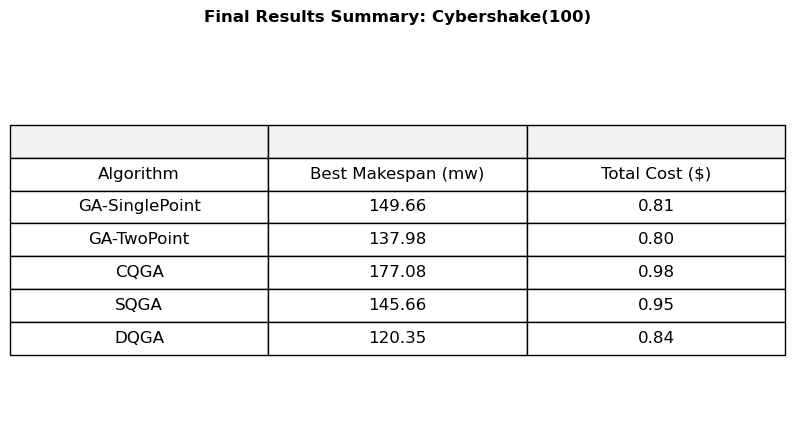

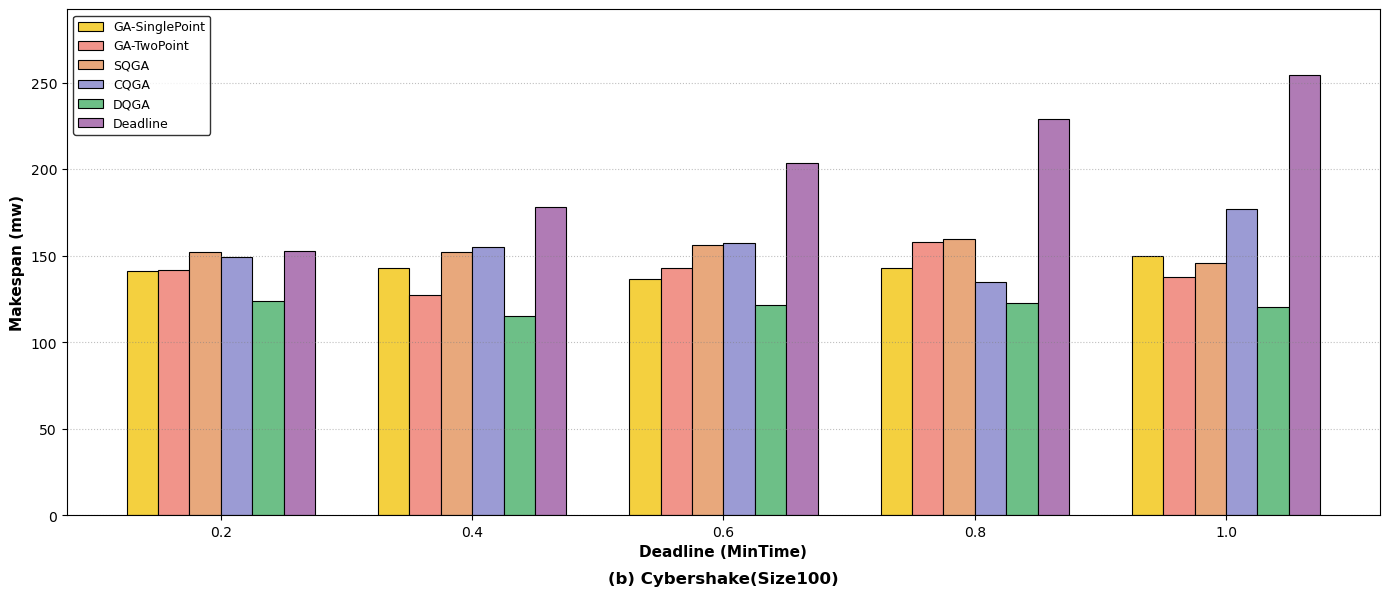

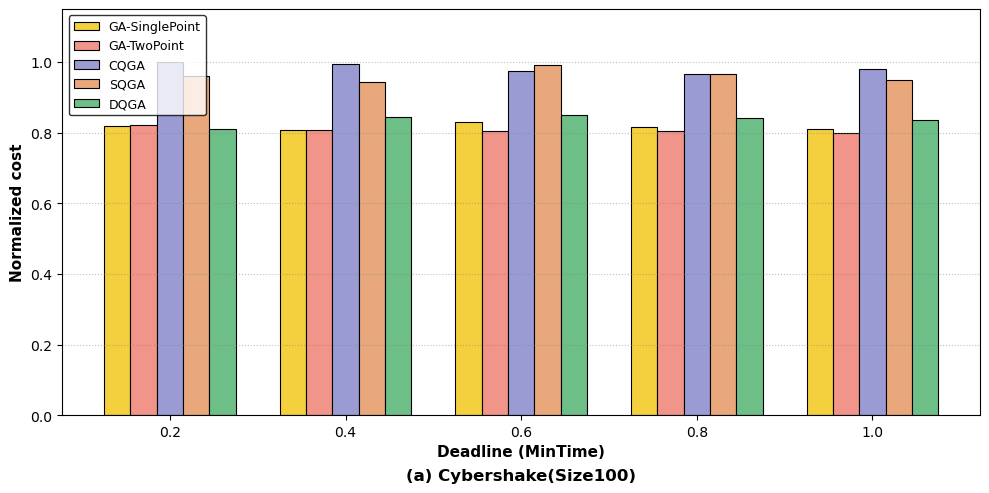


=== Running Cybershake(Size500) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
Baseline EFT_W computed inline: 126.30ms
-> Testing gamma 0.2 | Deadline (Dw): 151.56ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
-> Testing gamma 0.4 | Deadline (Dw): 176.83ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.6 | Deadline (Dw): 202.09ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7

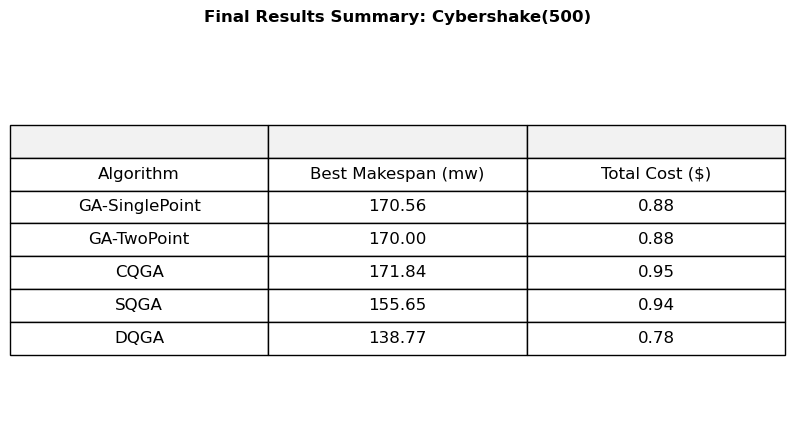

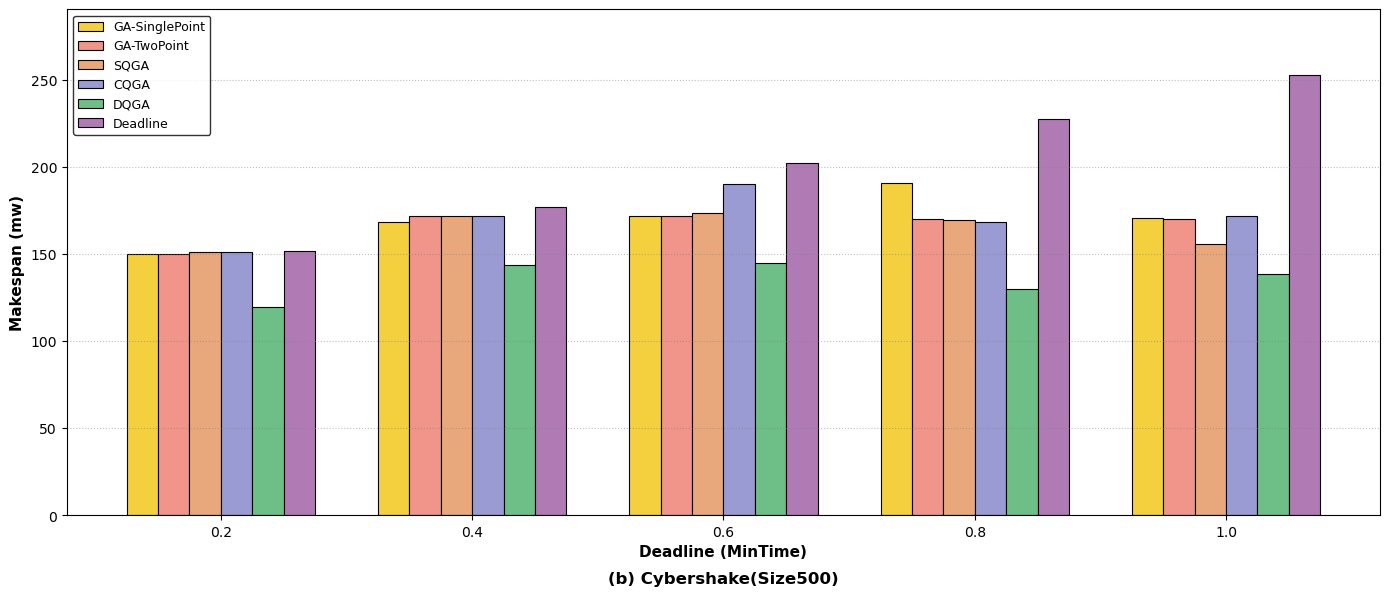

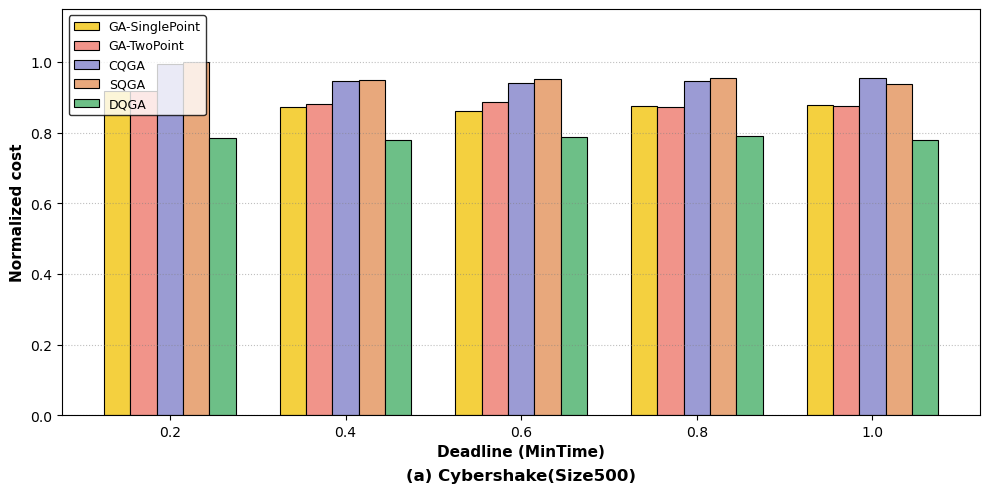


=== Running Cybershake(Size1000) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
Baseline EFT_W computed inline: 145.15ms
-> Testing gamma 0.2 | Deadline (Dw): 174.18ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0.7049 (Prob of '1' = 0.4969)
-> Testing gamma 0.4 | Deadline (Dw): 203.21ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.6 | Deadline (Dw): 232.24ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0

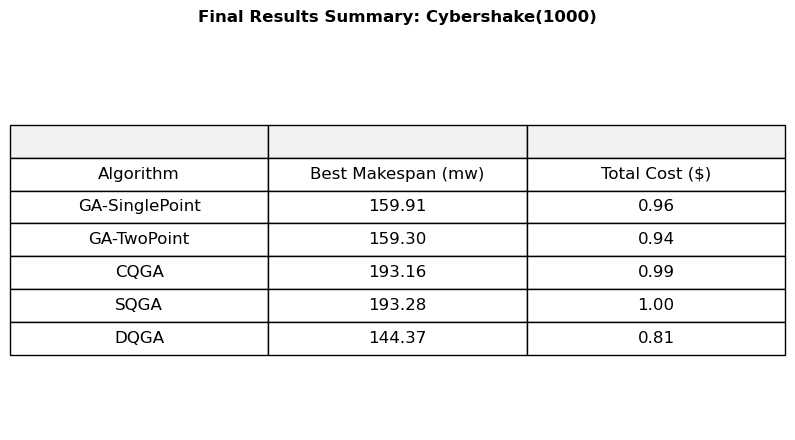

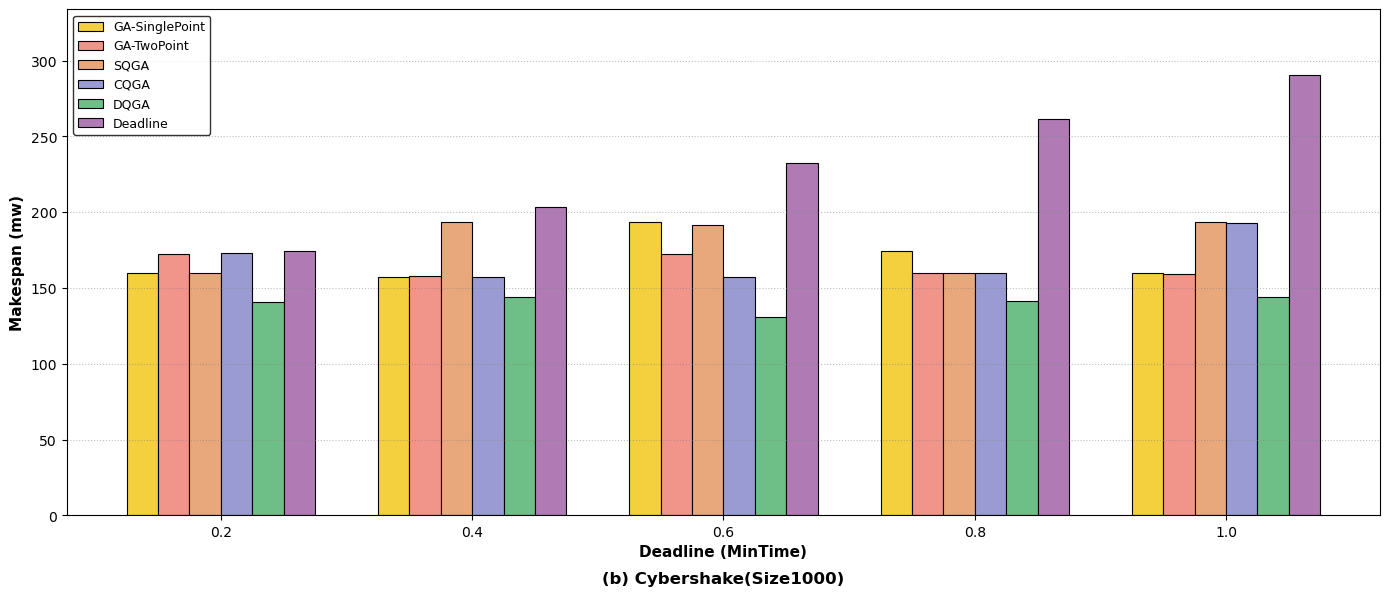

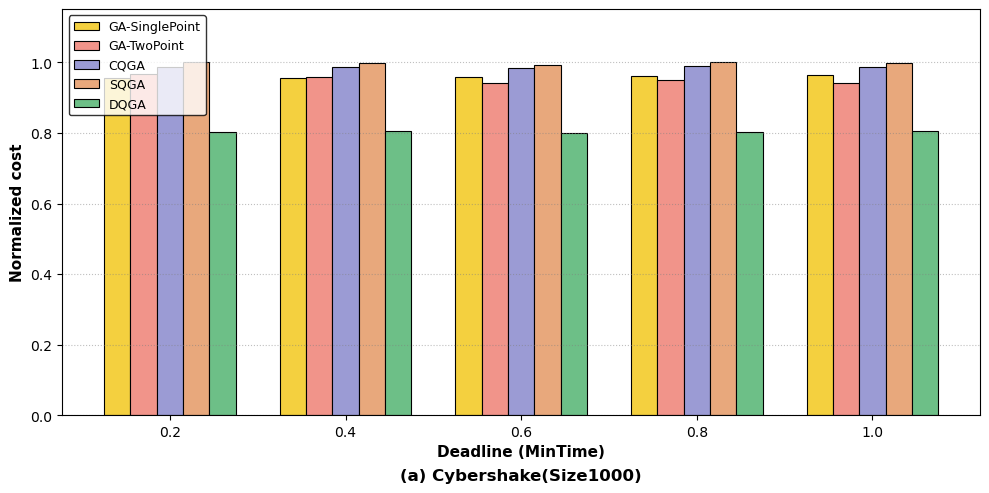


=== Running Epigenomic(Size100) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
Baseline EFT_W computed inline: 158.88ms
-> Testing gamma 0.2 | Deadline (Dw): 190.66ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.4 | Deadline (Dw): 222.43ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 0, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.6 | Deadline (Dw): 254.21ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7

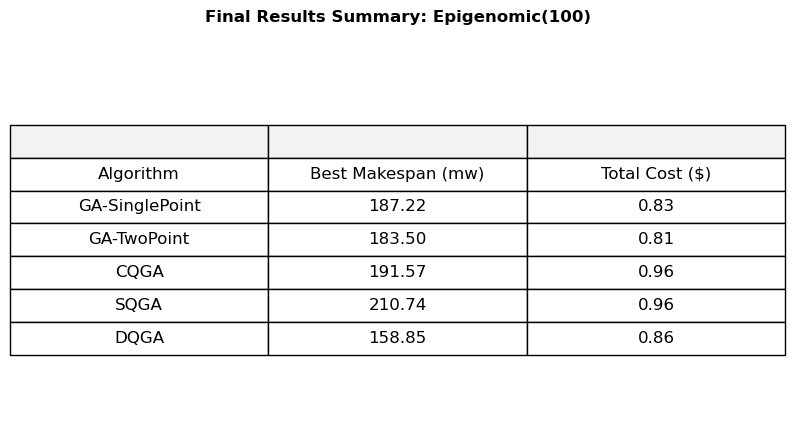

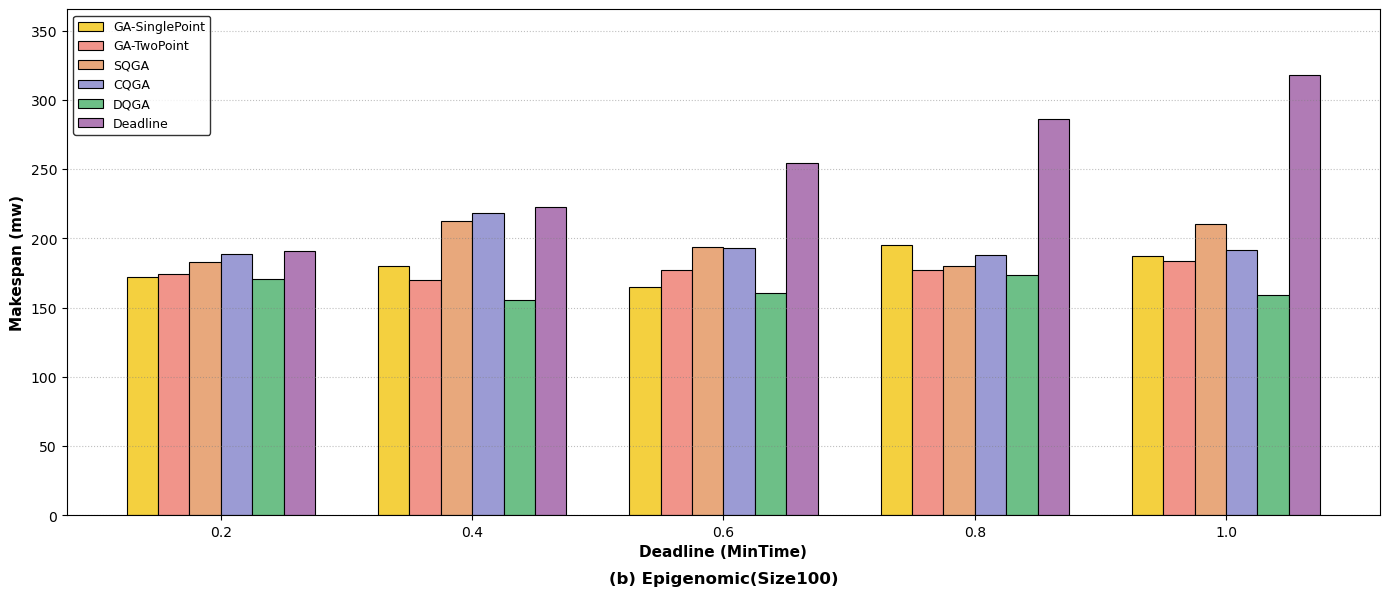

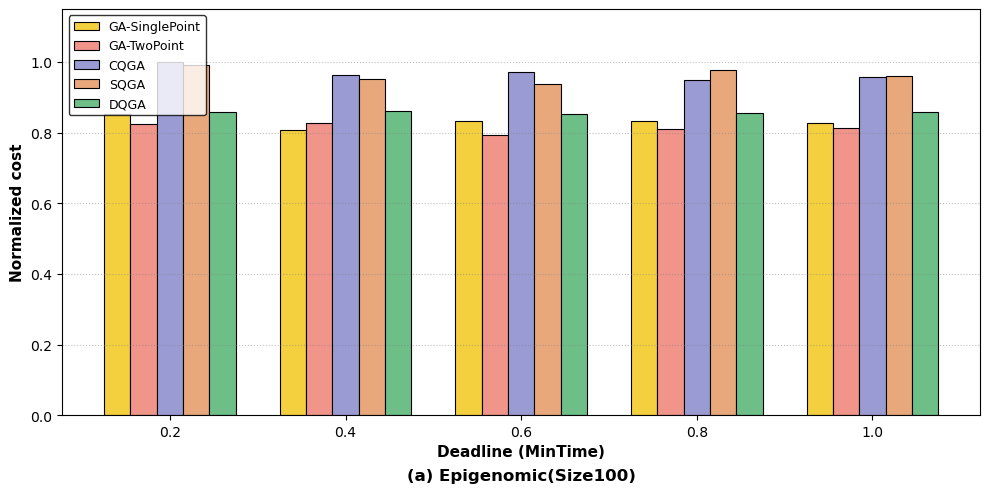


=== Running Epigenomic(Size500) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
Baseline EFT_W computed inline: 147.79ms
-> Testing gamma 0.2 | Deadline (Dw): 177.35ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
-> Testing gamma 0.4 | Deadline (Dw): 206.91ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.6 | Deadline (Dw): 236.47ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7

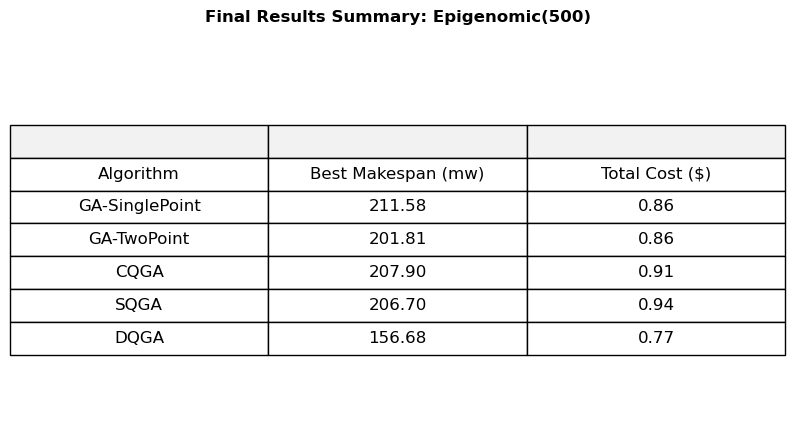

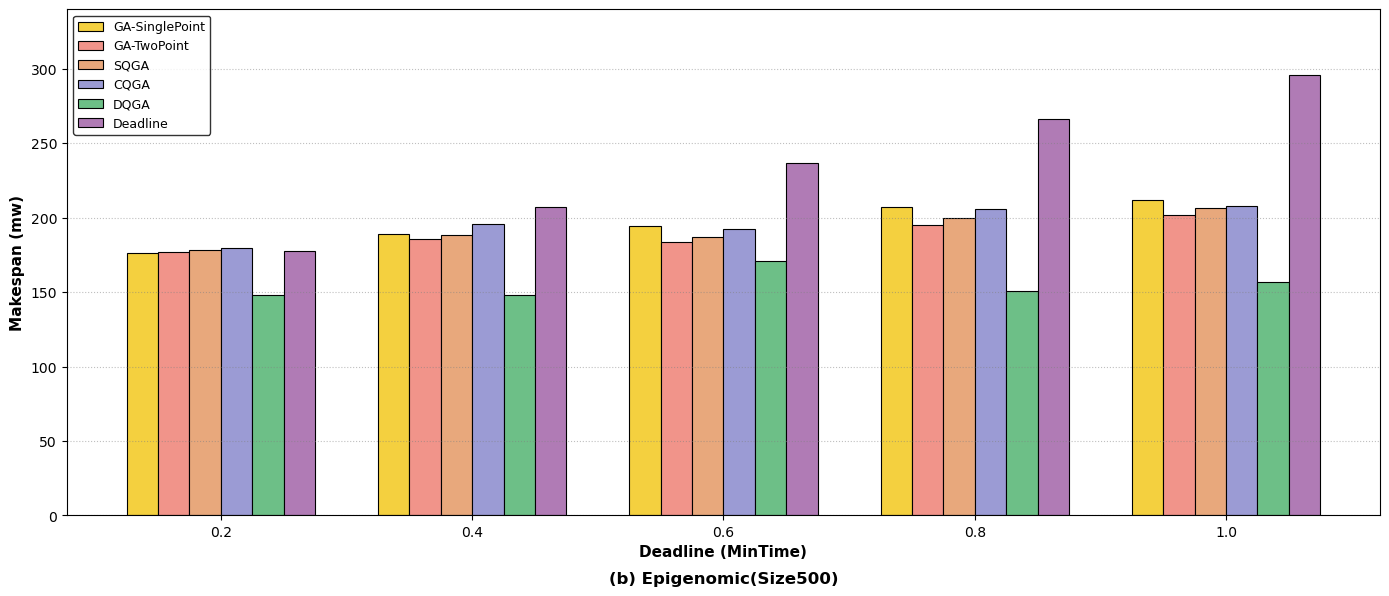

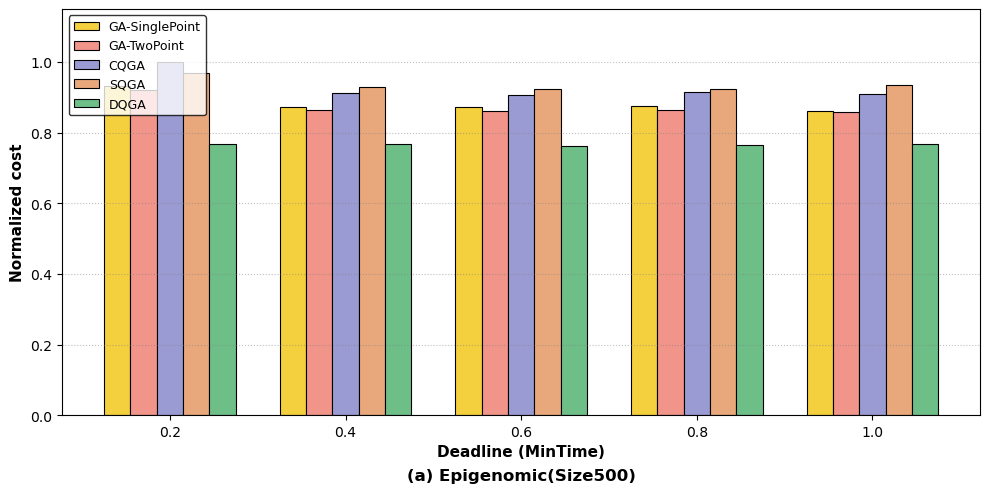


=== Running Epigenomic(Size1000) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 0, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
Baseline EFT_W computed inline: 148.47ms
-> Testing gamma 0.2 | Deadline (Dw): 178.17ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0.7049 (Prob of '1' = 0.4969)
-> Testing gamma 0.4 | Deadline (Dw): 207.86ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.6 | Deadline (Dw): 237.56ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0

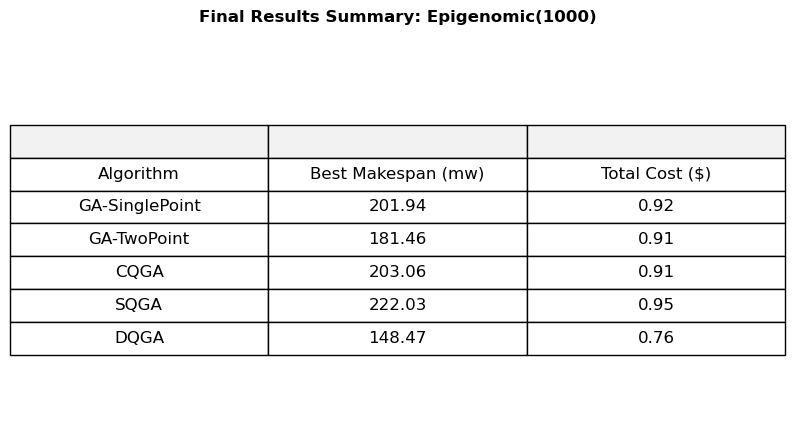

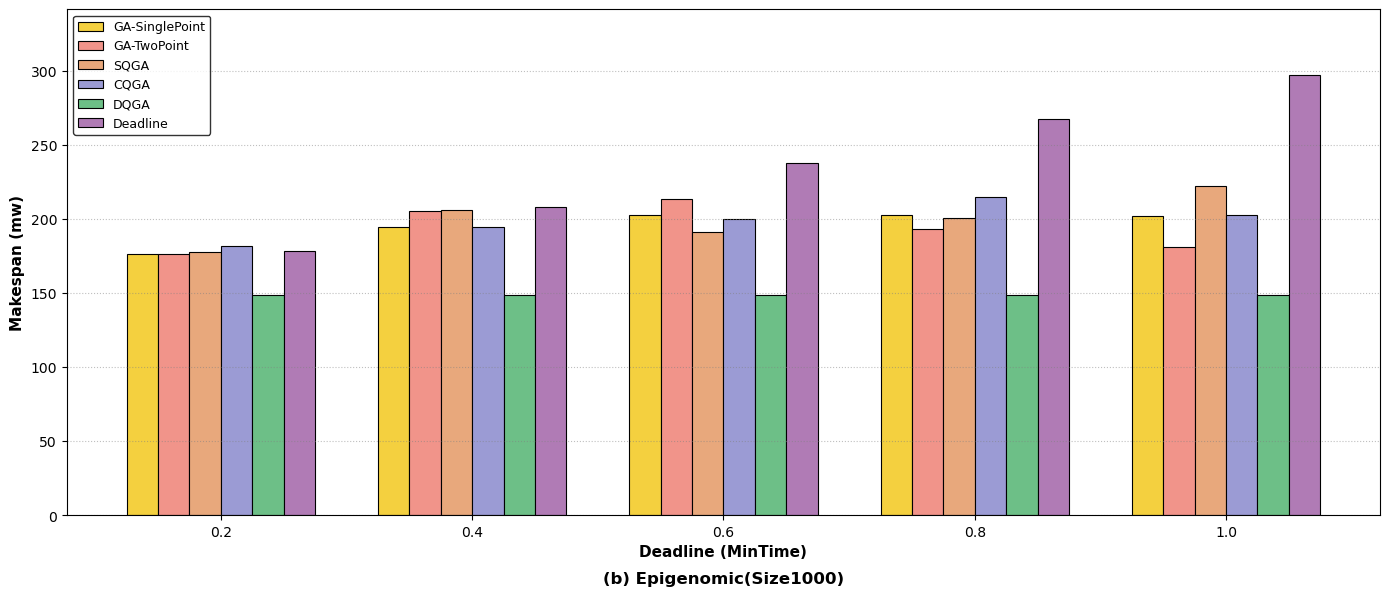

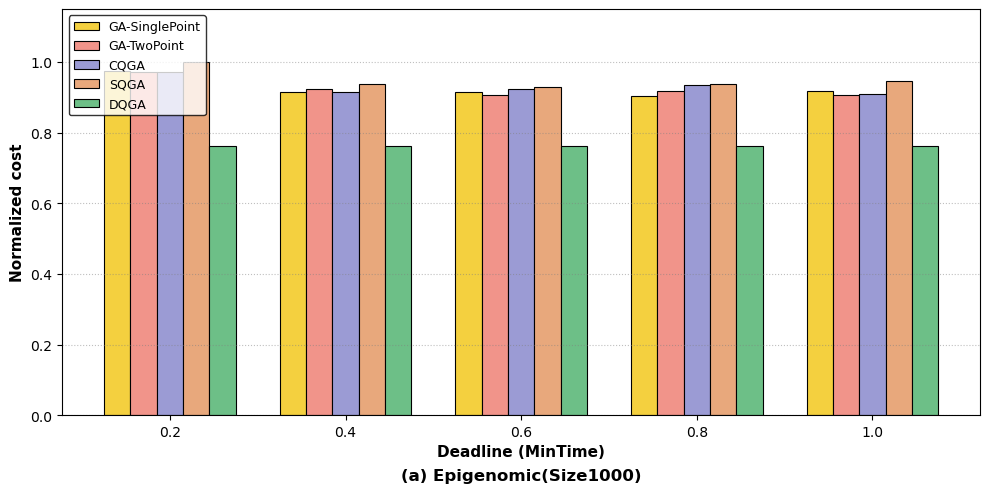


=== Running Montage(Size100) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 0, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
Baseline EFT_W computed inline: 90.73ms
-> Testing gamma 0.2 | Deadline (Dw): 108.87ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0.7049 (Prob of '1' = 0.4969)
-> Testing gamma 0.4 | Deadline (Dw): 127.02ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0.7049 (Prob of '1' = 0.4969)
-> Testing gamma 0.6 | Deadline (Dw): 145.16ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.709

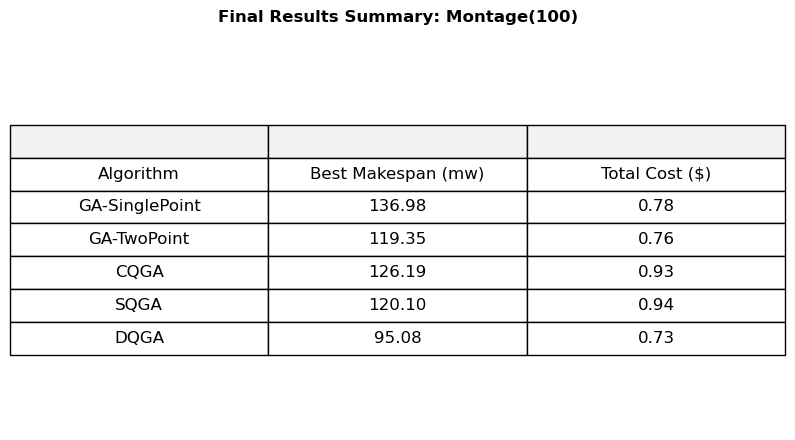

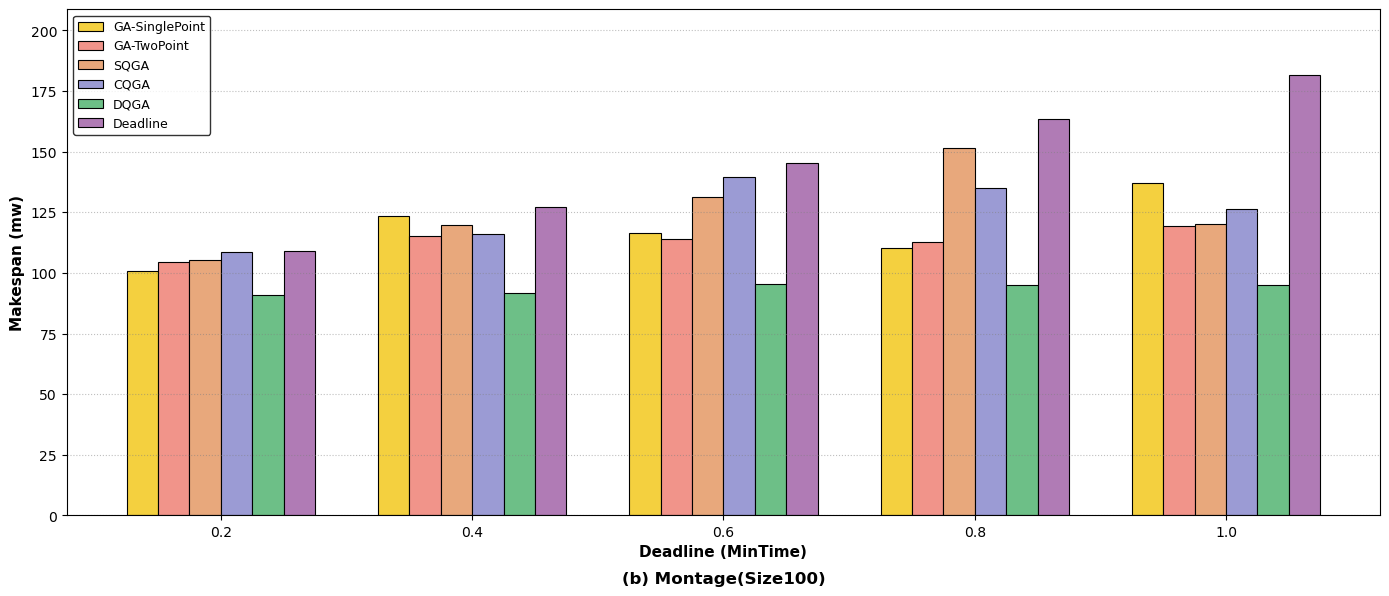

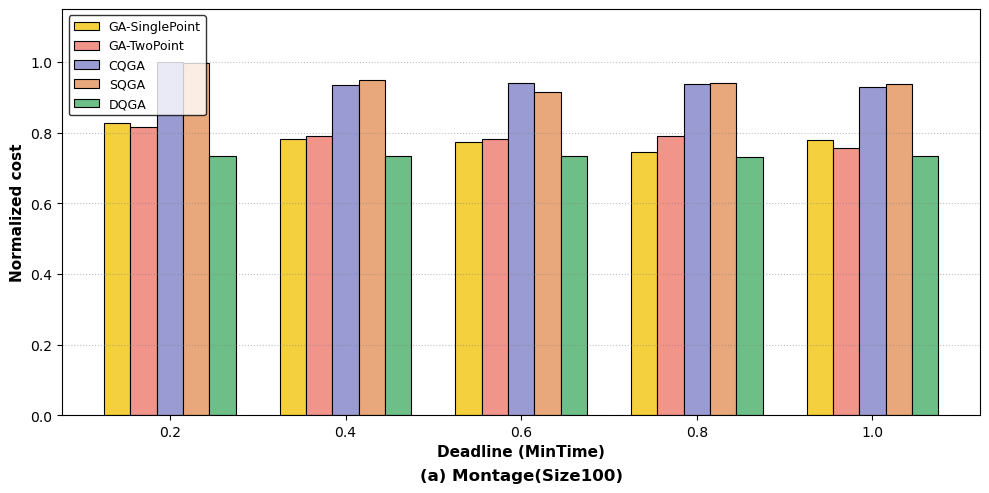


=== Running Montage(Size500) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
Baseline EFT_W computed inline: 96.07ms
-> Testing gamma 0.2 | Deadline (Dw): 115.29ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
-> Testing gamma 0.4 | Deadline (Dw): 134.50ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0.7049 (Prob of '1' = 0.4969)
-> Testing gamma 0.6 | Deadline (Dw): 153.72ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071

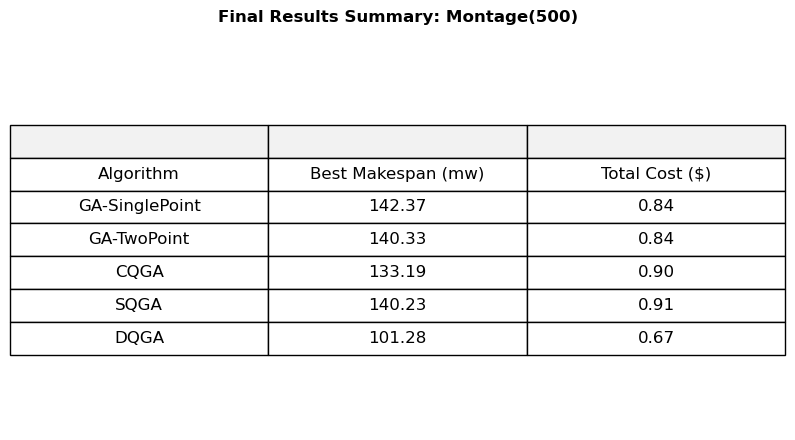

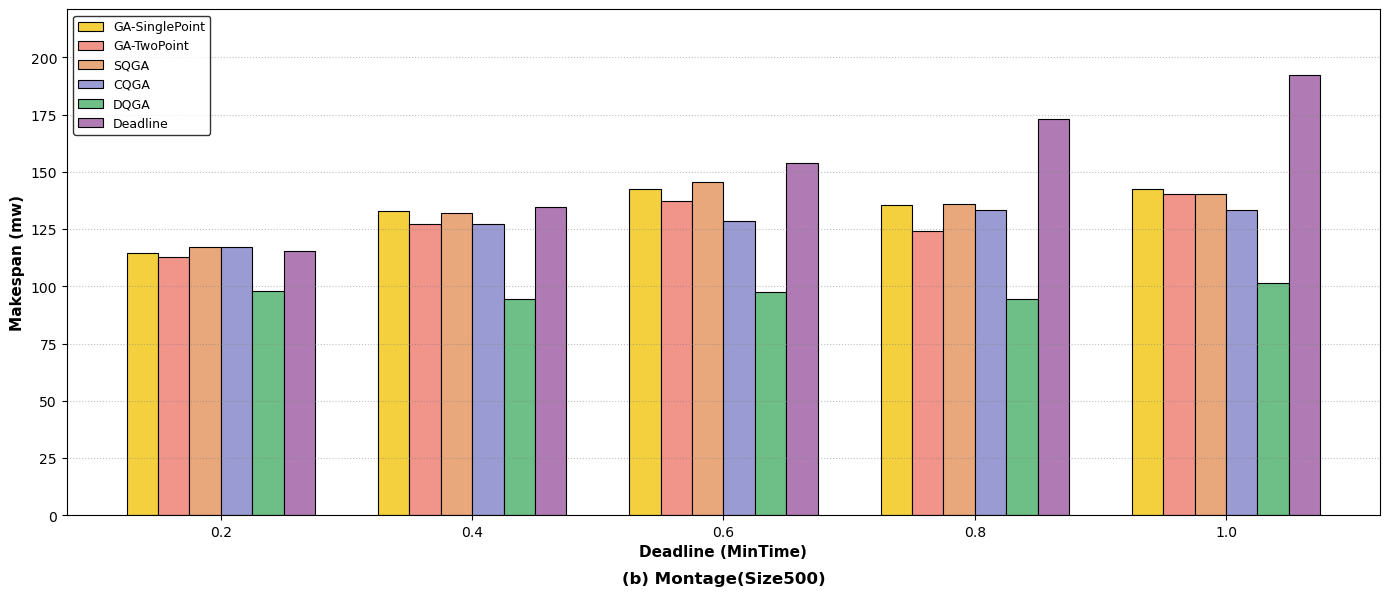

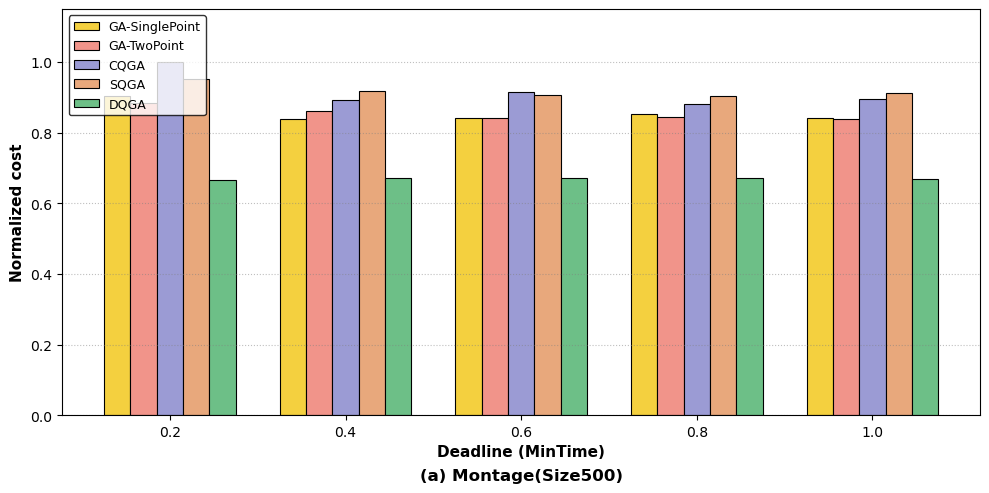


=== Running Montage(Size1000) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 0, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
Baseline EFT_W computed inline: 104.98ms
-> Testing gamma 0.2 | Deadline (Dw): 125.98ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.4 | Deadline (Dw): 146.98ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
-> Testing gamma 0.6 | Deadline (Dw): 167.97ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.707

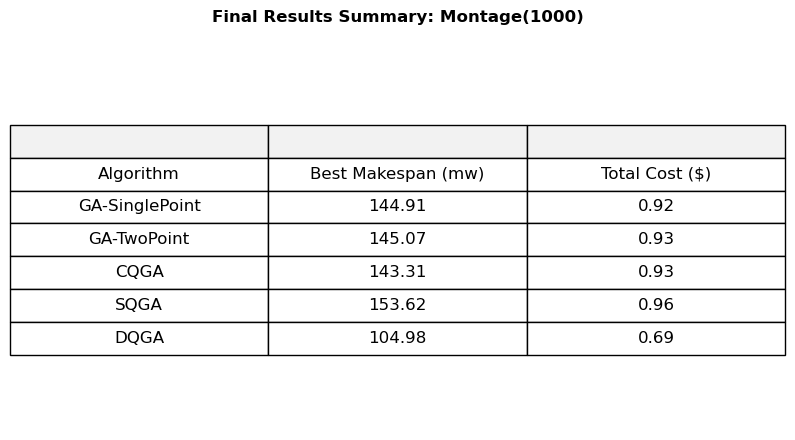

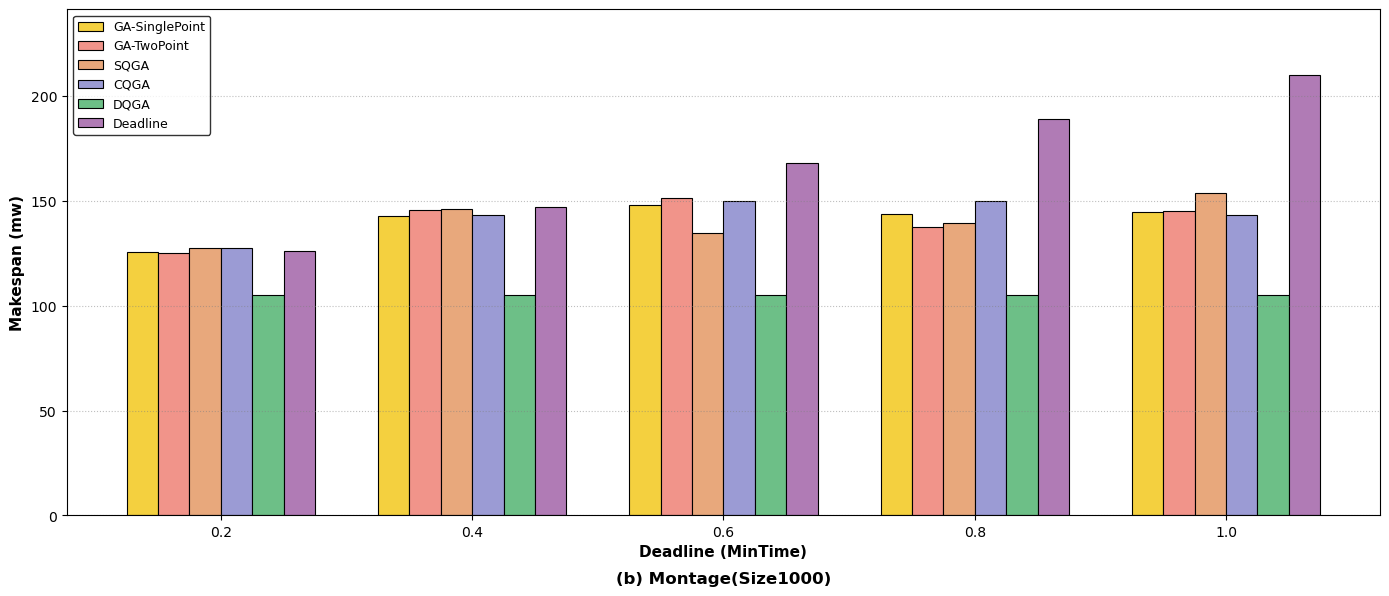

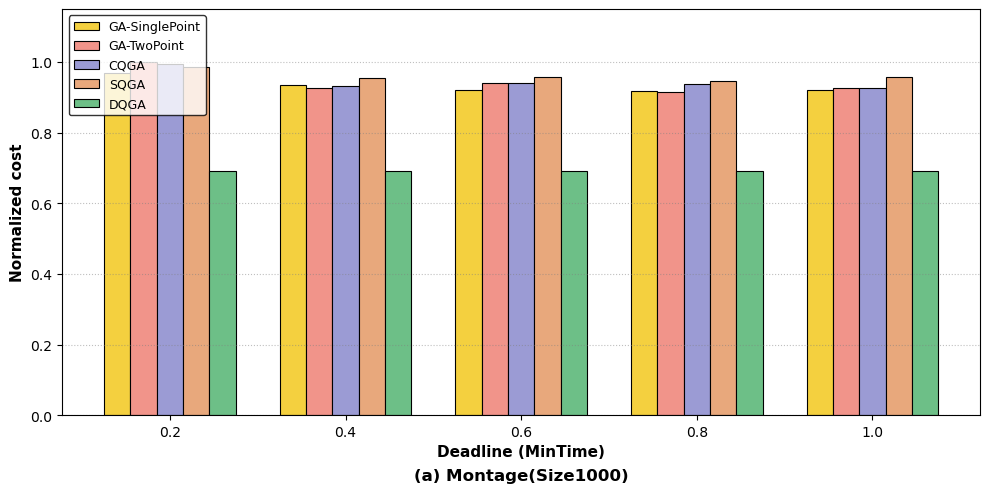


=== Running Sphilt(Size100) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
Baseline EFT_W computed inline: 55.73ms
-> Testing gamma 0.2 | Deadline (Dw): 66.87ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.4 | Deadline (Dw): 78.02ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
-> Testing gamma 0.6 | Deadline (Dw): 89.16ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0.7049 (Pr

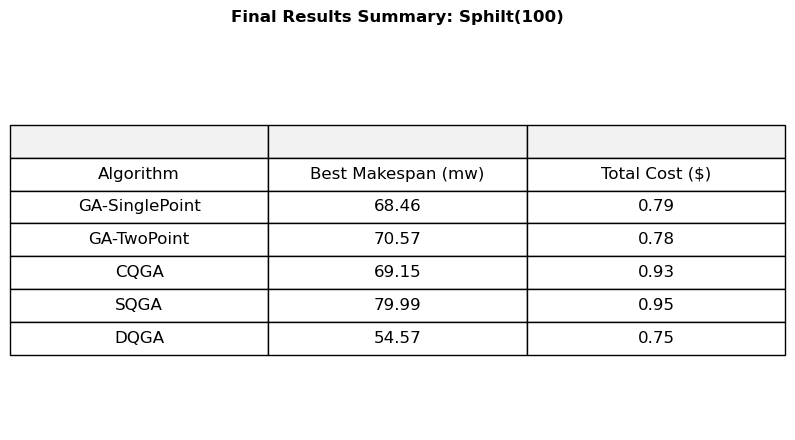

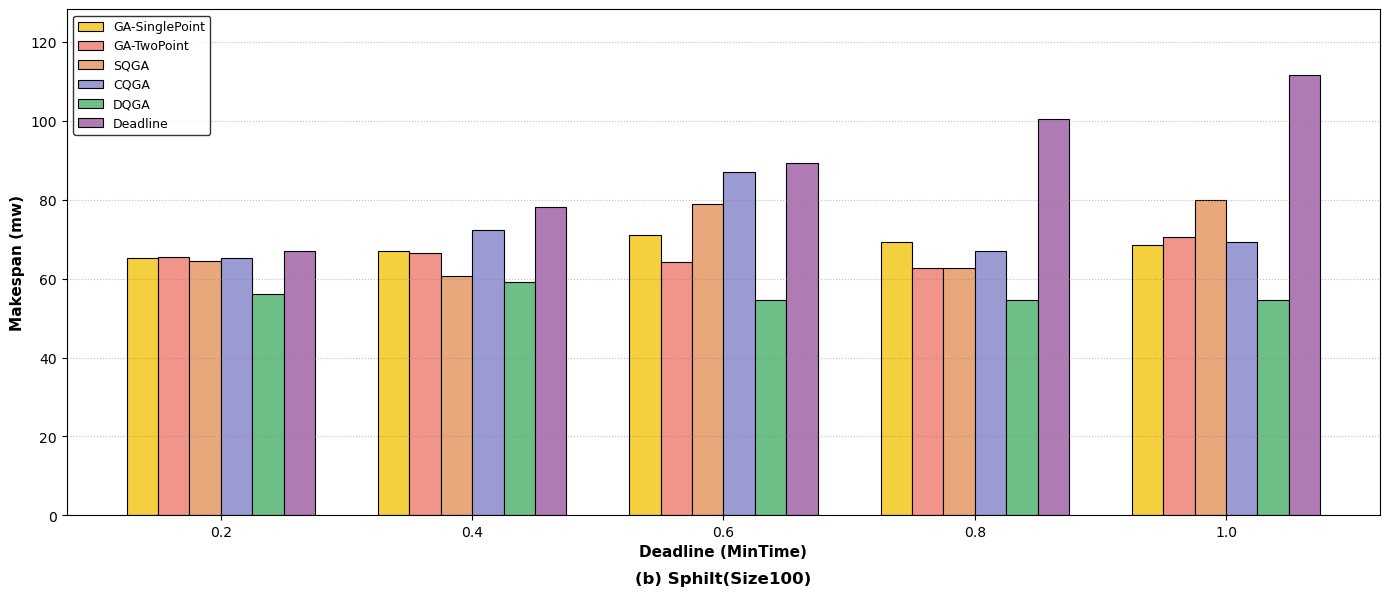

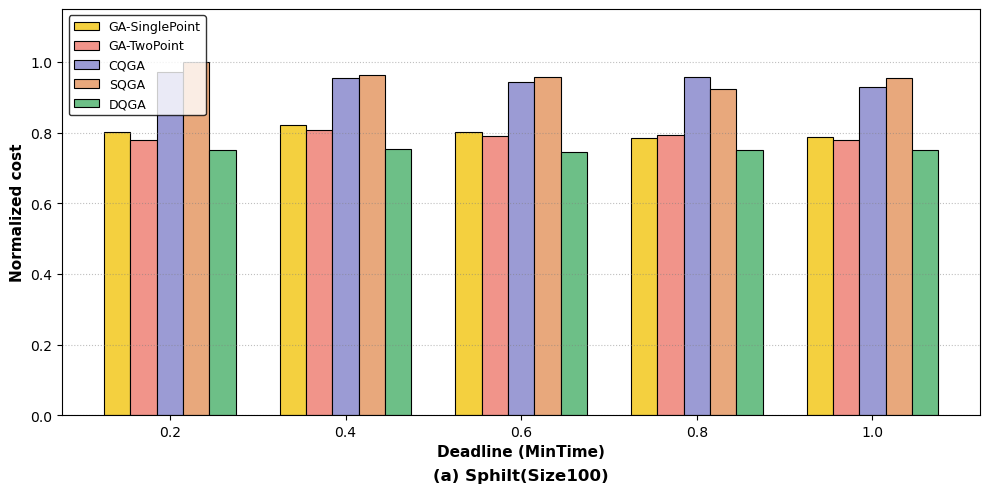


=== Running Sphilt(Size500) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
Baseline EFT_W computed inline: 55.34ms
-> Testing gamma 0.2 | Deadline (Dw): 66.40ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 0, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.4 | Deadline (Dw): 77.47ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0.7049 (Prob of '1' = 0.4969)
-> Testing gamma 0.6 | Deadline (Dw): 88.54ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 0, Target was: 1, Angle: -0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7093, β=0.7049 (P

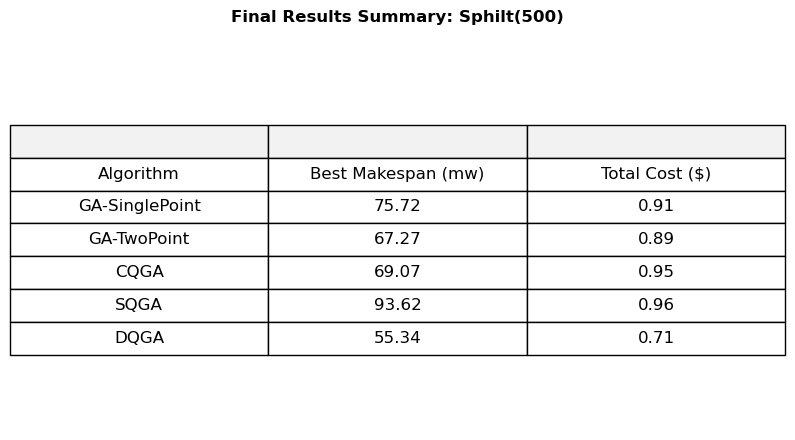

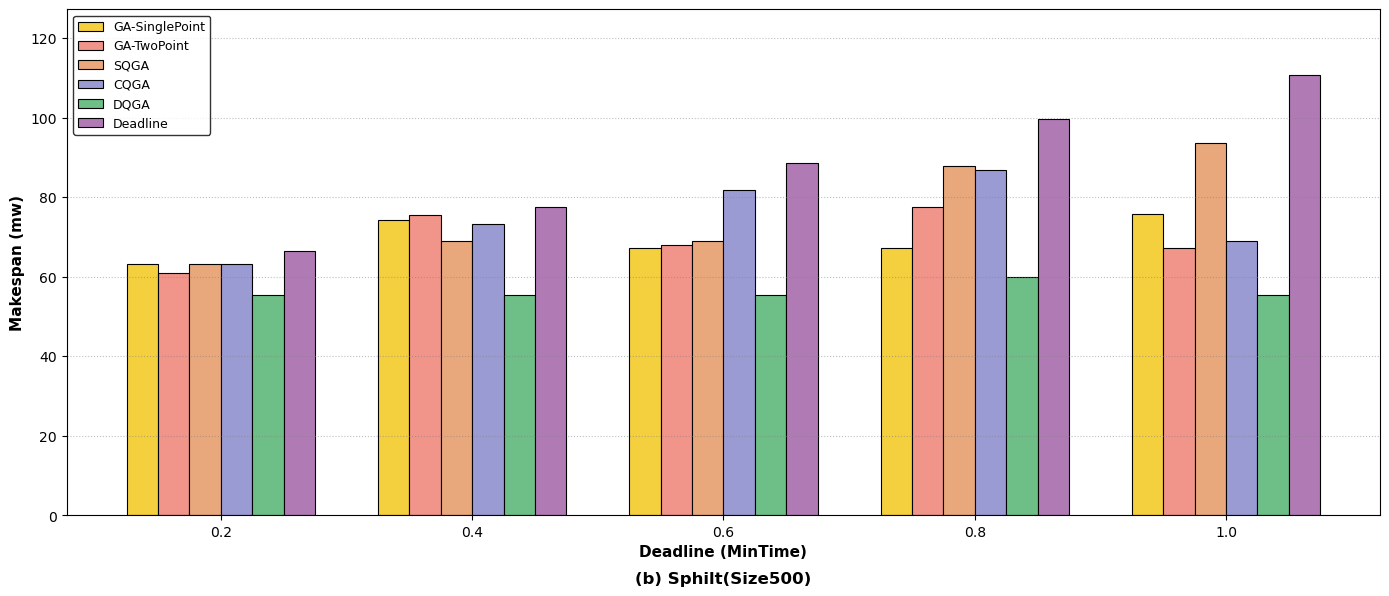

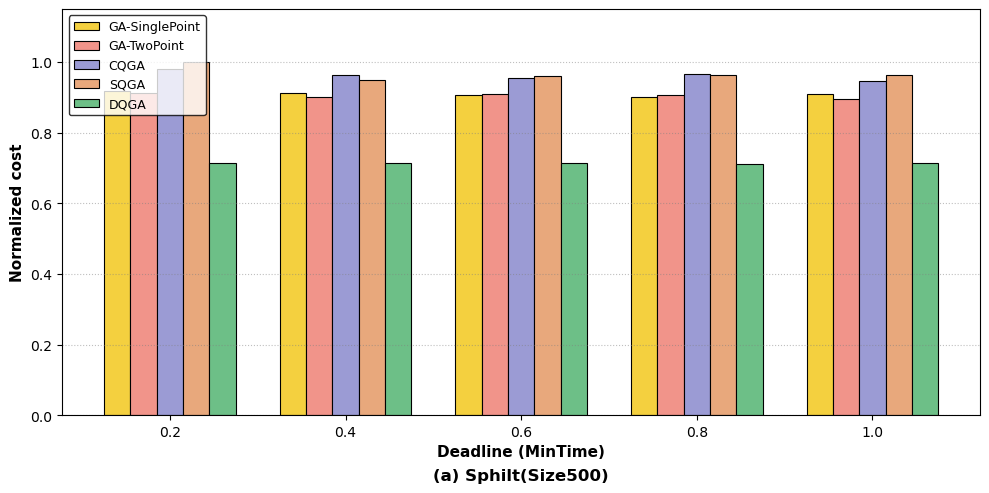


=== Running Sphilt(Size1000) ===

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 0, Angle: 0.003142
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7049, β=0.7093 (Prob of '1' = 0.5031)
Baseline EFT_W computed inline: 45.12ms
-> Testing gamma 0.2 | Deadline (Dw): 54.14ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.4 | Deadline (Dw): 63.17ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Prob of '1' = 0.5000)
-> Testing gamma 0.6 | Deadline (Dw): 72.19ms

--- Rotation Gate Check (Gen 0, Ind 0, Qubit 0) ---
Bit was: 1, Target was: 1, Angle: 0.000000
Old State: α=0.5774, β=0.5774 (Prob of '1' = 0.3333)
New State: α=0.7071, β=0.7071 (Pr

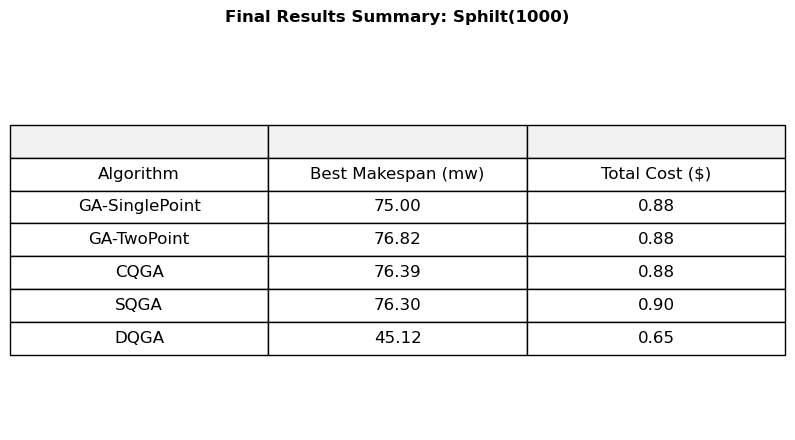

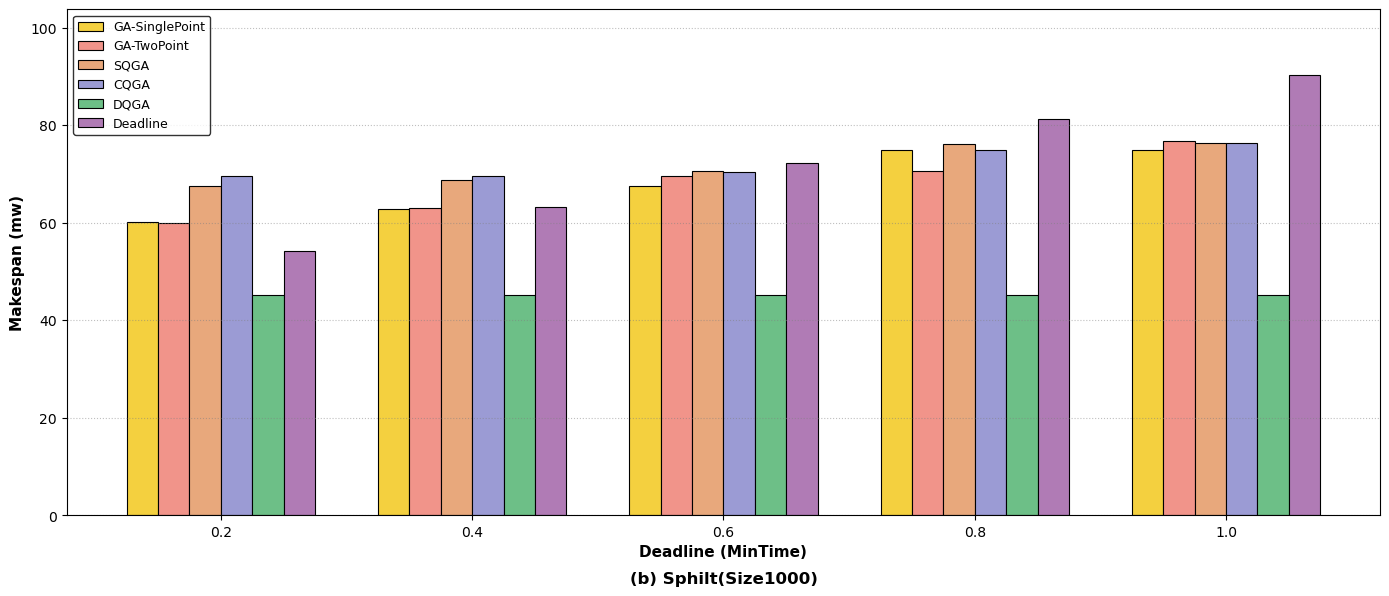

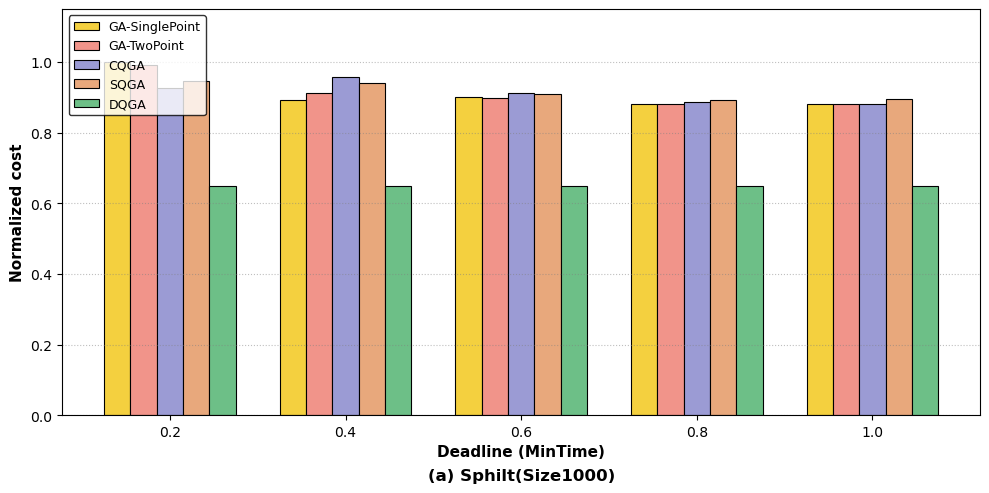

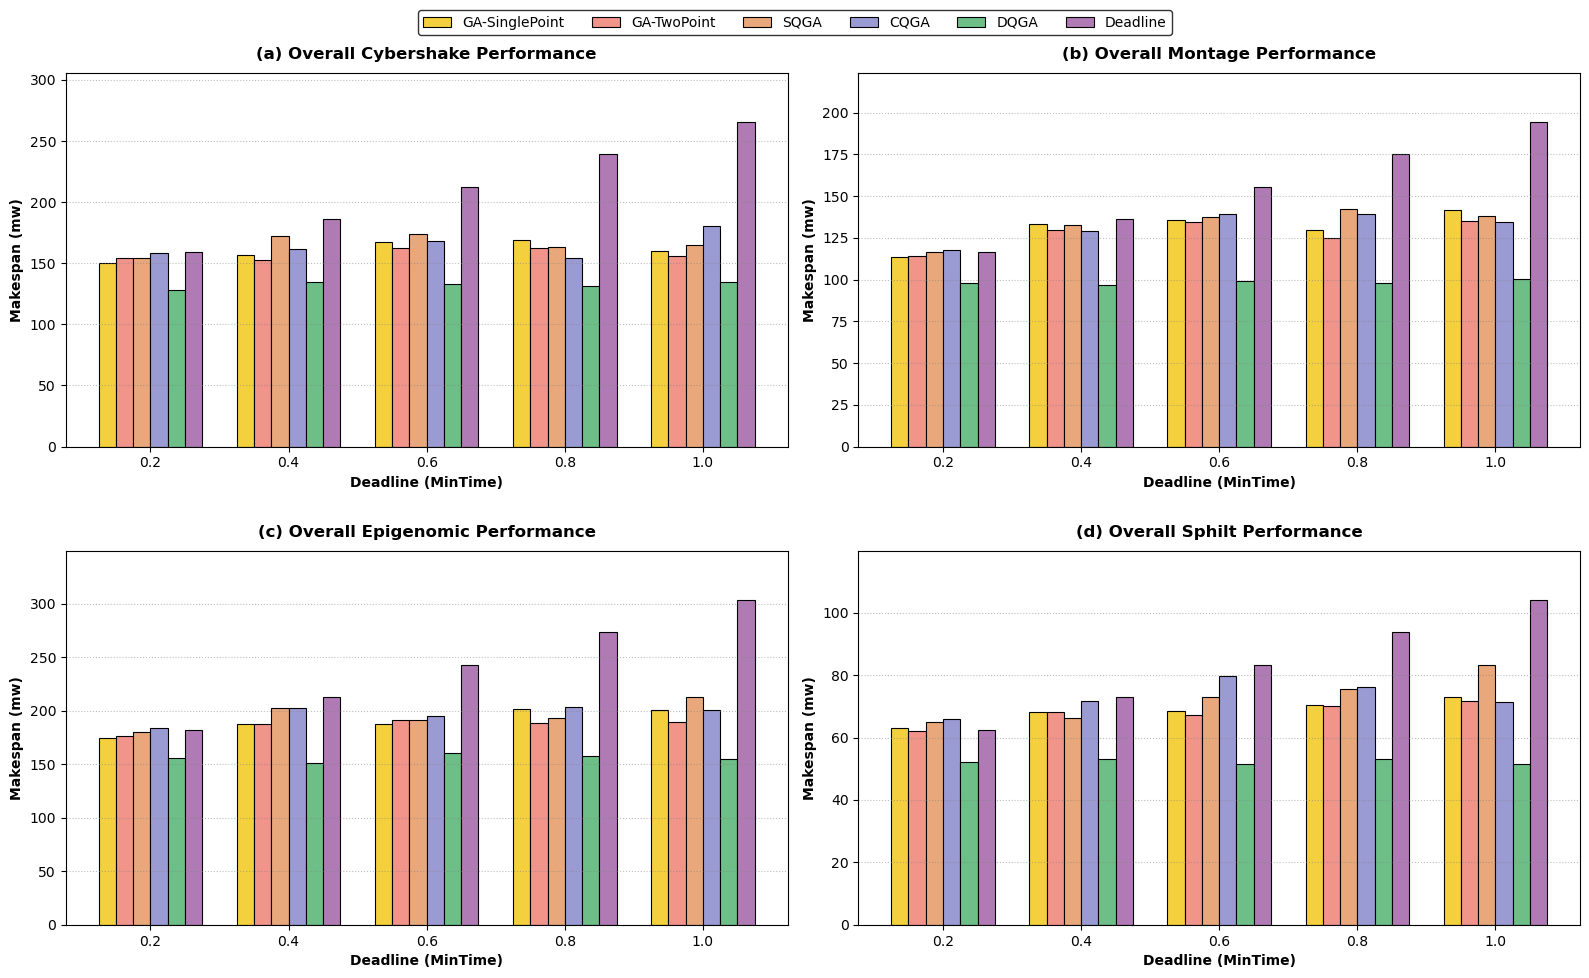

In [36]:
if __name__ == "__main__":
    main()